## Step 0 — Libraries

In [22]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.20.0
GPU: True


## Step 1 — Load Data

The enriched CSV files add 9 new covariate columns to the original Sentinel-2 time-series.  
File naming convention: `MCTNet_<State>_2021_enriched.csv`


In [23]:
from google.colab import drive
drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/Colab Notebooks'
print('Files:', sorted(os.listdir(FOLDER)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files: ['Classification.ipynb', 'Copy_of_Fine_tuning_Antonymes.ipynb', 'Fine_Tuning_synonymes (1).ipynb', 'MCTNet_Arkansas_2021_enriched.csv', 'MCTNet_Arkansas_2021_enriched_fixed.csv', 'MCTNet_California_2021_enriched.csv', 'MCTNet_California_2021_enriched_fixed.csv', 'MCTNet_Full_Pipeline_Part3_FIXED.ipynb', 'NeurNetworks-Project-Part1.ipynb', 'NeurNetworks_Part2_Ablation_FIXED_v2.ipynb', 'NeurNetworks_Part3_GRU_IMPROVED(1).ipynb', 'NeurNetworks_Part3_GRU_IMPROVED.ipynb', 'Part_1_final.ipynb', 'Projet Res Neur.ipynb', 'Untitled', 'Untitled (1)', 'Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled3.ipynb', 'ablation_arkansas.csv', 'ablation_arkansas_part2.csv', 'ablation_arkansas_part3_improved.csv', 'ablation_california.csv', 'ablation_california_part2.csv', 'ablation_california_part3_improved.csv', 'ablation_combined.csv', 'ablation_combined_part2.csv', 'ablat

In [24]:
df_ar = pd.read_csv(os.path.join(FOLDER, 'MCTNet_Arkansas_2021_enriched_fixed.csv'))
df_ca = pd.read_csv(os.path.join(FOLDER, 'MCTNet_California_2021_enriched_fixed.csv'))

# ── Sentinel-2 spectral columns ───────────────────────────────────────────────
BANDS       = ['Blue', 'Green', 'NIR', 'RE1', 'RE2', 'RE3', 'RE4', 'Red', 'SWIR1', 'SWIR2']
N_TIMESTEPS = 36
N_BANDS     = 10

SPEC_COLS  = [f'{b}_t{t:02d}' for t in range(1, N_TIMESTEPS+1) for b in BANDS]
VALID_COLS = [f'valid_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]

# ── Climate covariate columns (now per-10-day period: 3 bands × 36 steps = 108) ─
# Each climate band has 36 temporal columns aligned with the Sentinel-2 windows.
CLIM_BANDS = ['clim_temp_mean_C', 'clim_precip_sum_m', 'clim_dewpoint_mean_C']
CLIM_COLS  = [f'{b}_t{t:02d}' for b in CLIM_BANDS for t in range(1, N_TIMESTEPS+1)]
# 108 columns: clim_temp_mean_C_t01…t36, clim_precip_sum_m_t01…t36, clim_dewpoint_mean_C_t01…t36

SOIL_COLS  = ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
TOPO_COLS  = ['topo_elevation_m', 'topo_landform_class']

# Numerical covariates: 108 climate + 2 soil numeric + 2 topo numeric = 112
COVAR_NUM  = CLIM_COLS + ['soil_organic_carbon_g_kg', 'soil_pH', 'topo_elevation_m']
COVAR_CAT  = ['soil_texture_class', 'topo_landform_class']   # unchanged
ALL_COVARS = COVAR_NUM + COVAR_CAT

# ── Summary climate columns for EDA visualisation (mean/sum across time) ─────
# These are NOT used for training — only for readability in plots.
CLIM_DISPLAY = {
    'clim_temp_mean_C'      : 'mean',   # annual mean temperature
    'clim_precip_sum_m'     : 'sum',    # annual precipitation total
    'clim_dewpoint_mean_C'  : 'mean',   # annual mean dewpoint
}
def add_clim_display_cols(df):
    """Add 3 scalar summary columns for EDA visualisation."""
    for prefix, agg in CLIM_DISPLAY.items():
        cols = [f'{prefix}_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]
        if agg == 'mean':
            df[f'{prefix}_annual'] = df[cols].mean(axis=1)
        else:
            df[f'{prefix}_annual'] = df[cols].sum(axis=1)
    return df

df_ar = add_clim_display_cols(df_ar)
df_ca = add_clim_display_cols(df_ca)

COVAR_DISPLAY_NUM = ['clim_temp_mean_C_annual', 'clim_precip_sum_m_annual',
                     'clim_dewpoint_mean_C_annual',
                     'soil_organic_carbon_g_kg', 'soil_pH', 'topo_elevation_m']

# ── Label dictionaries ────────────────────────────────────────────────────────
AR_LABELS = {0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton', 4: 'Others'}
CA_LABELS = {0: 'Grapes',   1: 'Rice', 2: 'Alfalfa', 3: 'Almonds',
             4: 'Pistachios', 5: 'Others'}

print('Arkansas :', df_ar.shape)
print(df_ar['label'].value_counts().sort_index().rename(AR_LABELS))
print(f'CLIM_COLS ({len(CLIM_COLS)}): {CLIM_COLS[:3]} … {CLIM_COLS[-3:]}')
print(f'ALL_COVARS total: {len(ALL_COVARS)}')
print('\nCalifornia:', df_ca.shape)
print(df_ca['label'].value_counts().sort_index().rename(CA_LABELS))


Arkansas : (10000, 519)
label
Soybeans    4704
Rice        2488
Corn        1392
Cotton       806
Others       610
Name: count, dtype: int64
CLIM_COLS (108): ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] … ['clim_dewpoint_mean_C_t34', 'clim_dewpoint_mean_C_t35', 'clim_dewpoint_mean_C_t36']
ALL_COVARS total: 113

California: (10000, 519)
label
Grapes        2008
Rice          1856
Alfalfa        985
Almonds        808
Pistachios     585
Others        3758
Name: count, dtype: int64



## New Attributes Added to the Enriched Datasets


In [ ]:
new_attrs = {
    'Attribute'   : [
        'clim_temp_mean_C_t01…t36   (×36)', 'clim_precip_sum_m_t01…t36  (×36)',
        'clim_dewpoint_mean_C_t01…t36 (×36)',
        'soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class',
        'topo_elevation_m', 'topo_landform_class',
    ],
    'Group'       : ['Climate']*3 + ['Soil']*3 + ['Topography']*2,
    'Type'        : ['Numerical (float)']*6 + ['Numerical (float)', 'Categorical (int)'],
    'Temporality' : ['Per-10-day step (×36)']*3 + ['Static (per pixel)']*5,
    'Description' : [
        'Mean 2m air temperature per 10-day window (°C)',
        'Total precipitation per 10-day window (m)',
        'Mean dewpoint temperature per 10-day window (°C) — VPD proxy',
        'Soil organic carbon content at topsoil (g/kg)',
        'Soil pH (0–14 scale)',
        'USDA soil texture class 1–12',
        'Terrain elevation above sea level (m)',
        'ALOS geomorphological landform class',
    ],
}

df_attrs = pd.DataFrame(new_attrs)
display(df_attrs)

print(f'\nTotal new columns: {len(CLIM_COLS)} climate + 3 soil + 2 topo = {len(CLIM_COLS)+5}')
print(f'  Climate: {len(CLIM_COLS)} (3 bands × 36 time steps)')
print(f'  Soil   : 3 (static)')
print(f'  Topo   : 2 (static)')

# Column presence check
print('\nVerifying columns exist in both states:')
check_cols = CLIM_COLS[:3] + CLIM_COLS[-3:] + ['soil_organic_carbon_g_kg','soil_pH',
              'soil_texture_class','topo_elevation_m','topo_landform_class']
for state, df in [('Arkansas', df_ar), ('California', df_ca)]:
    missing = [c for c in CLIM_COLS + SOIL_COLS + TOPO_COLS if c not in df.columns]
    status = f'✓ all {len(CLIM_COLS+SOIL_COLS+TOPO_COLS)} present' if not missing else f'✗ MISSING: {missing}'
    print(f'  {state}: {status}')

for state, df in [('Arkansas', df_ar), ('California', df_ca)]:
    print(f'\nDisplay-summary covariate stats ({state}):')
    print(df[COVAR_DISPLAY_NUM].describe().round(3))


,Attribute,Group,Type,Temporality,Description
0,clim_temp_mean_C_t01…t36 (×36),Climate,Numerical (float),Per-10-day step (×36),Mean 2m air temperature per 10-day window (°C)
1,clim_precip_sum_m_t01…t36 (×36),Climate,Numerical (float),Per-10-day step (×36),Total precipitation per 10-day window (m)
2,clim_dewpoint_mean_C_t01…t36 (×36),Climate,Numerical (float),Per-10-day step (×36),Mean dewpoint temperature per 10-day window (°...
3,soil_organic_carbon_g_kg,Soil,Numerical (float),Static (per pixel),Soil organic carbon content at topsoil (g/kg)
4,soil_pH,Soil,Numerical (float),Static (per pixel),Soil pH (0–14 scale)
5,soil_texture_class,Soil,Numerical (float),Static (per pixel),USDA soil texture class 1–12
6,topo_elevation_m,Topography,Numerical (float),Static (per pixel),Terrain elevation above sea level (m)
7,topo_landform_class,Topography,Categorical (int),Static (per pixel),ALOS geomorphological landform class



Total new columns: 108 climate + 3 soil + 2 topo = 113
  Climate: 108 (3 bands × 36 time steps)
  Soil   : 3 (static)
  Topo   : 2 (static)

Verifying columns exist in both states:
  Arkansas: ✓ all 113 present
  California: ✓ all 113 present

Display-summary covariate stats (Arkansas):
       clim_temp_mean_C_annual  clim_precip_sum_m_annual  \
count                10000.000                 10000.000   
mean                    17.109                     1.364   
std                      0.698                     0.080   
min                     14.822                     1.091   
25%                     16.568                     1.287   
50%                     17.121                     1.365   
75%                     17.600                     1.424   
max                     18.799                     1.645   

       clim_dewpoint_mean_C_annual  soil_organic_carbon_g_kg    soil_pH  \
count                    10000.000                 10000.000  10000.000   
mean                

## Part 1.3 — Data Exploration

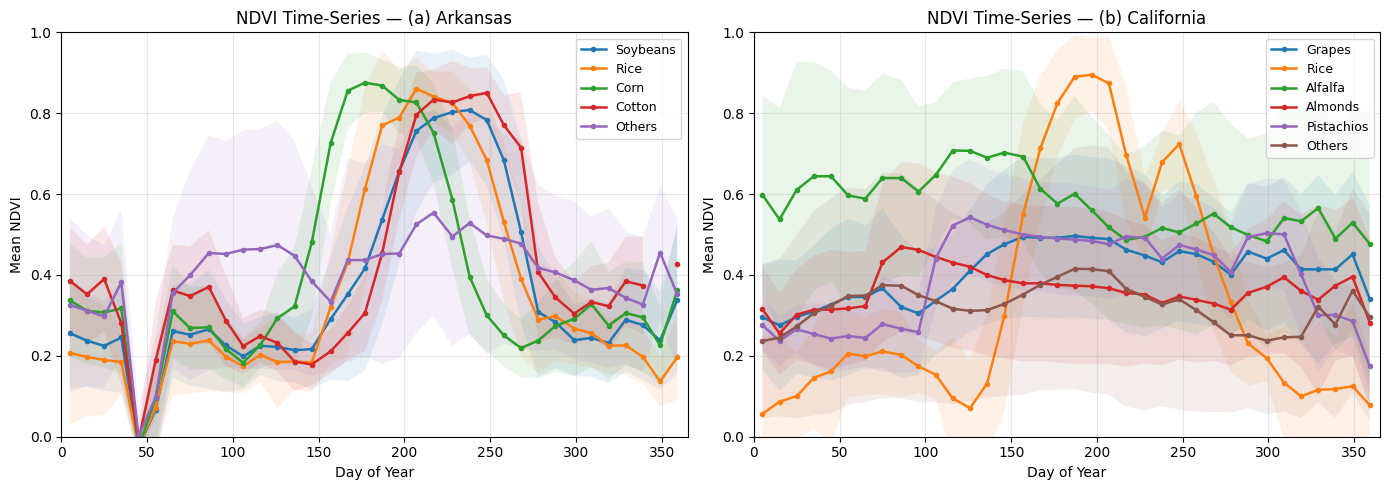

In [26]:
DOY = [int((t - 1) * 365 / N_TIMESTEPS) + 5 for t in range(1, N_TIMESTEPS + 1)]

def compute_ndvi(df):
    nir   = df[[f'NIR_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]].values.astype('float32')
    red   = df[[f'Red_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]].values.astype('float32')
    valid = df[VALID_COLS].values.astype('float32')
    nir   = np.where(valid == 1, nir, np.nan)
    red   = np.where(valid == 1, red, np.nan)
    return np.clip((nir - red) / (nir + red + 1e-8), -1.0, 1.0)

ndvi_ar = compute_ndvi(df_ar)
ndvi_ca = compute_ndvi(df_ca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, ndvi, label_map, title in [
    (axes[0], df_ar, ndvi_ar, AR_LABELS, '(a) Arkansas'),
    (axes[1], df_ca, ndvi_ca, CA_LABELS, '(b) California')
]:
    for code_lbl, name in label_map.items():
        m   = df['label'].values == code_lbl
        mu  = np.nanmean(ndvi[m], axis=0)
        std = np.nanstd(ndvi[m], axis=0)
        ax.plot(DOY, mu, marker='o', markersize=3, linewidth=1.8, label=name)
        ax.fill_between(DOY, mu - std, mu + std, alpha=0.10)
    ax.set_title(f'NDVI Time-Series — {title}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Mean NDVI')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


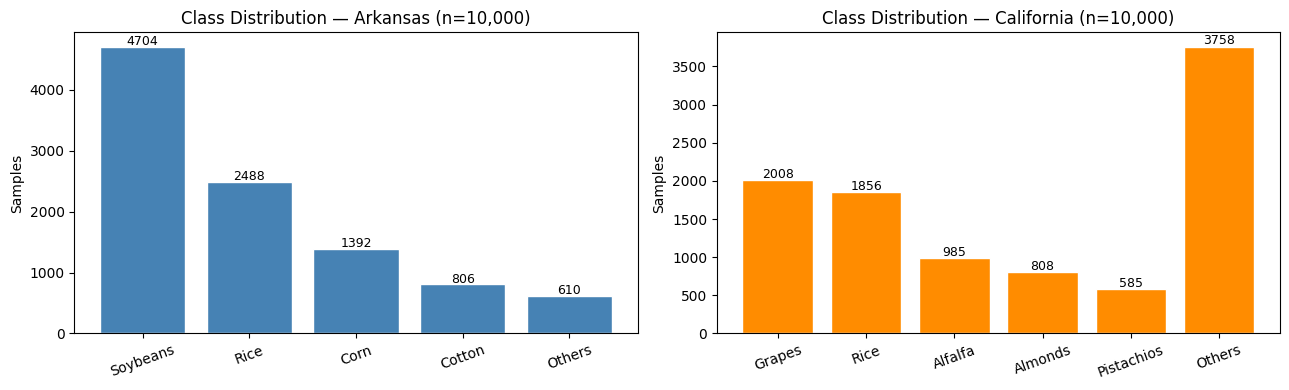

Missing observations — Arkansas: 19.6%  |  California: 13.4%
Zeros = cloud-masked observations. They stay as 0 (ALPE handles them via the mask).


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, label_map, color, title in [
    (axes[0], df_ar, AR_LABELS, 'steelblue',  'Arkansas'),
    (axes[1], df_ca, CA_LABELS, 'darkorange', 'California')
]:
    counts = df['label'].value_counts().sort_index()
    names  = [label_map[i] for i in counts.index]
    ax.bar(names, counts.values, color=color, edgecolor='white')
    ax.set_title(f'Class Distribution — {title} (n=10,000)')
    ax.set_ylabel('Samples')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

ar_miss = (1 - df_ar[VALID_COLS].values.mean()) * 100
ca_miss = (1 - df_ca[VALID_COLS].values.mean()) * 100
print(f'Missing observations — Arkansas: {ar_miss:.1f}%  |  California: {ca_miss:.1f}%')
print('Zeros = cloud-masked observations. They stay as 0 (ALPE handles them via the mask).')


---
## Part 1.4 -- Preprocessing

In [ ]:
def paper_split(y, n_trainval=300, val_frac=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    tr_idx, va_idx, te_idx = [], [], []
    for cls in np.unique(y):
        idx  = rng.permutation(np.where(y == cls)[0])
        tv   = idx[:n_trainval]
        rest = idx[n_trainval:]
        n_va = int(len(tv) * val_frac)
        va_idx.extend(tv[:n_va])
        tr_idx.extend(tv[n_va:])
        te_idx.extend(rest)
    return np.array(tr_idx), np.array(va_idx), np.array(te_idx)


def build_covariate_encoder(df_train_rows):
    ct = ColumnTransformer([
        ('num', StandardScaler(),       COVAR_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COVAR_CAT),
    ])
    ct.fit(df_train_rows[ALL_COVARS])
    return ct


def preprocess(df, label_map, state):
    # split FIRST, then fit normalisation on training rows only.

    print(f'\n--- {state} ---')

    X    = df[SPEC_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, N_BANDS)
    mask = df[VALID_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, 1)
    y    = df['label'].values.astype('int32')

    # Split first
    tr_i, va_i, te_i = paper_split(y)
    print(f'  Train: {len(tr_i)} | Val: {len(va_i)} | Test: {len(te_i)}')

    # compute scale on training samples only
    X_tr_flat   = X[tr_i]
    valid_vals  = X_tr_flat[X_tr_flat > 0]
    v_min = float(valid_vals.min())
    v_max = float(X_tr_flat.max())
    X = np.where(X > 0, (X - v_min) / (v_max - v_min + 1e-8), 0.0).astype('float32')
    print(f'  Spectral norm (train-only): v_min={v_min:.4f}  v_max={v_max:.4f}')

    covar_encoder = build_covariate_encoder(df.iloc[tr_i])
    C_all = covar_encoder.transform(df[ALL_COVARS]).astype('float32')
    print(f'  Covariate feature size (after encoding): {C_all.shape[1]}')

    class_names = [label_map[i] for i in sorted(label_map)]
    return (
        (X[tr_i], mask[tr_i], C_all[tr_i], y[tr_i]),
        (X[va_i], mask[va_i], C_all[va_i], y[va_i]),
        (X[te_i], mask[te_i], C_all[te_i], y[te_i]),
        class_names,
        covar_encoder
    )


ar_train, ar_val, ar_test, ar_classes, ar_enc = preprocess(df_ar, AR_LABELS, 'Arkansas')
ca_train, ca_val, ca_test, ca_classes, ca_enc = preprocess(df_ca, CA_LABELS, 'California')

N_COVAR_AR = ar_train[2].shape[1]
N_COVAR_CA = ca_train[2].shape[1]
print(f'\nArkansas covariate dim : {N_COVAR_AR}')
print(f'California covariate dim: {N_COVAR_CA}')



--- Arkansas ---
  Train: 1200 | Val: 300 | Test: 8500
  Spectral norm (train-only): v_min=0.0006  v_max=1.2384
  Covariate feature size (after encoding): 126

--- California ---
  Train: 1440 | Val: 360 | Test: 8200
  Spectral norm (train-only): v_min=0.0000  v_max=1.2778
  Covariate feature size (after encoding): 127

Arkansas covariate dim : 126
California covariate dim: 127


## Part 1.5 — MCTNet Architecture

In [ ]:
# Sinusoidal positional encoding
def sinusoidal_pe(T, dm):
    pe  = np.zeros((T, dm), dtype='float32')
    pos = np.arange(T)[:, np.newaxis]
    div = np.exp(np.arange(0, dm, 2) * (-np.log(10000.0) / dm))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe

PE_MATRIX = sinusoidal_pe(N_TIMESTEPS, N_BANDS)


class ALPELayer(keras.layers.Layer):
    def __init__(self, dm, **kwargs):
        super().__init__(**kwargs)
        self.pe       = tf.constant(PE_MATRIX[np.newaxis], dtype=tf.float32)
        self.conv     = layers.Conv1D(dm, kernel_size=3, padding='same')
        self.eca_conv = layers.Conv1D(1,  kernel_size=3, padding='same')
    def call(self, mask):
        masked_pe = self.pe * tf.cast(mask, tf.float32)
        x   = self.conv(masked_pe)
        gap = tf.expand_dims(tf.reduce_mean(x, axis=1), axis=-1)
        gap = tf.squeeze(tf.sigmoid(self.eca_conv(gap)), axis=-1)
        return x * tf.expand_dims(gap, axis=1)


def cnn_sub(x, filters, kernel_size=3):
    shortcut = x if x.shape[-1] == filters else layers.Conv1D(filters, 1, padding='same')(x)
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    return layers.Activation('relu')(layers.Add()([x, shortcut]))


def transformer_sub(x, n_heads, pos_enc=None):
    if pos_enc is not None:
        x = layers.Add()([x, pos_enc])
    d    = x.shape[-1]
    attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=max(1, d // n_heads))(x, x)
    x    = layers.LayerNormalization()(layers.Add()([x, attn]))
    ff   = layers.Dense(d)(layers.Dense(d, activation='relu')(x))
    return layers.LayerNormalization()(layers.Add()([x, ff]))


def mctnet_backbone(inp_feat, inp_mask, n_heads=5):
    alpe_enc = ALPELayer(dm=N_BANDS, name='alpe')(inp_mask)
    cnn1 = cnn_sub(inp_feat, filters=10)
    tr1  = layers.Conv1D(10, 1, padding='same')(
               transformer_sub(inp_feat, n_heads, pos_enc=alpe_enc))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn1, tr1]))
    cnn2 = cnn_sub(x, filters=20)
    tr2  = layers.Conv1D(20, 1, padding='same')(transformer_sub(x, n_heads))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn2, tr2]))
    cnn3 = cnn_sub(x, filters=40)
    tr3  = layers.Conv1D(40, 1, padding='same')(transformer_sub(x, n_heads))
    return layers.GlobalMaxPooling1D()(layers.Concatenate()([cnn3, tr3]))


def build_mctnet(n_classes, T=N_TIMESTEPS, C=N_BANDS, n_heads=5):
    inp_feat = keras.Input(shape=(T, C), name='features')
    inp_mask = keras.Input(shape=(T, 1), name='mask')
    emb  = mctnet_backbone(inp_feat, inp_mask, n_heads)
    out  = layers.Dense(n_classes, activation='softmax')(emb)
    return keras.Model([inp_feat, inp_mask], out, name='MCTNet_baseline')



from tensorflow.keras.regularizers import l2 as _l2

# Gate bias initializers for better training stability with sigmoid gates
_GATE_BIAS_SINGLE = keras.initializers.Constant(-2.0)
_GATE_BIAS_GROUP  = keras.initializers.Constant(-3.0)
_COV_L2    = 1e-3

# Extended MCTNet with covariate gating
def build_mctnet_with_covariates(n_classes, n_covariates,
                                  group_sizes=None,
                                  gate_biases=None,
                                  T=N_TIMESTEPS, C=N_BANDS, n_heads=5):
    inp_feat  = keras.Input(shape=(T, C),          name='features')
    inp_mask  = keras.Input(shape=(T, 1),           name='mask')
    inp_covar = keras.Input(shape=(n_covariates,),  name='covariates')
    emb = mctnet_backbone(inp_feat, inp_mask, n_heads)

    if group_sizes is None or len(group_sizes) <= 1:
        cov  = layers.Dense(64, activation='relu',
                            kernel_regularizer=_l2(_COV_L2))(inp_covar)
        cov  = layers.Dense(32, activation='relu',
                            kernel_regularizer=_l2(_COV_L2))(cov)
        _gb_single = (
            keras.initializers.Constant(gate_biases)
            if isinstance(gate_biases, (int, float))
            else gate_biases[0]
            if isinstance(gate_biases, list)
            else _GATE_BIAS_SINGLE
        )
        gate = layers.Dense(1, activation='sigmoid',
                            bias_initializer=_gb_single,
                            name='gate_group_0')(inp_covar)
        cov_concat = layers.Multiply()([cov, gate])
    else:
        gated_parts = []
        offset = 0
        for i, n_g in enumerate(group_sizes):
            g_slice = layers.Lambda(
                lambda x, s=offset, e=offset + n_g: x[:, s:e],
                name=f'slice_group_{i}'
            )(inp_covar)
            hidden_dim = max(16, n_g // 4)
            embed_dim  = max(4,  n_g // 16)
            g_emb = layers.Dense(hidden_dim,
                                  kernel_regularizer=_l2(_COV_L2))(g_slice)
            g_emb = layers.BatchNormalization()(g_emb)
            g_emb = layers.Activation('relu')(g_emb)
            g_emb = layers.Dropout(0.30)(g_emb)
            g_emb = layers.Dense(embed_dim, activation='relu',
                                 kernel_regularizer=_l2(_COV_L2),
                                 name=f'embed_group_{i}')(g_emb)
            _gb_i = (
                gate_biases[i]
                if isinstance(gate_biases, list) and i < len(gate_biases)
                else _GATE_BIAS_GROUP
            )
            g_gate = layers.Dense(1, activation='sigmoid',
                                   bias_initializer=_gb_i,
                                   name=f'gate_group_{i}')(g_slice)
            gated_parts.append(
                layers.Multiply(name=f'gated_group_{i}')([g_emb, g_gate])
            )
            offset += n_g
        cov_concat = layers.Concatenate(name='all_gated_covars')(gated_parts)

    fused = layers.Concatenate(name='fused')([emb, cov_concat])
    out   = layers.Dense(n_classes, activation='softmax')(fused)
    return keras.Model([inp_feat, inp_mask, inp_covar], out,
                       name='MCTNet_per_group_gates')


def print_gate_diagnostics(model, test_data, group_names=None):
    if len(test_data) != 4:
        return
    Xte, mte, Cte, yte = test_data
    inputs = [Xte, mte, Cte]
    gate_layers = [l for l in model.layers if l.name.startswith('gate_group_')]
    if not gate_layers:
        return
    print('\n  Gate Values (mean over test set):')
    for i, gl in enumerate(sorted(gate_layers, key=lambda l: l.name)):
        gate_model = keras.Model(model.inputs, gl.output)
        gate_vals  = gate_model.predict(inputs, verbose=0).flatten()
        label      = group_names[i] if group_names and i < len(group_names) else gl.name
        bar        = '#' * int(gate_vals.mean() * 20)
        print(f'  {label:15s}: {gate_vals.mean():.3f} +/- {gate_vals.std():.3f}  |{bar}')
    print()


demo = build_mctnet(n_classes=5)
demo.summary()
print(f'Baseline parameters: {demo.count_params():,}')
demo2 = build_mctnet_with_covariates(n_classes=5, n_covariates=N_COVAR_AR)
print(f'Extended (single gate): {demo2.count_params():,}')
demo3 = build_mctnet_with_covariates(n_classes=5, n_covariates=N_COVAR_AR,
                                      group_sizes=[108, 3, 2])
print(f'Extended (per-group):   {demo3.count_params():,}')



Model: "MCTNet_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mask (InputLayer)   │ (None, 36, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alpe (ALPELayer)    │ (None, 36, 10)    │        314 │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 36, 10)    │          0 │ features[0][0],   │
│                     │                   │            │ alpe[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │        440 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 36, 10)    │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 10)    │        310 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 10)    │         20 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 10)    │         40 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 10)    │        310 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 36, 10)    │        110 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 36, 10)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 36, 10)    │          0 │ batch_normalizat… │
│                     │                   │            │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 36, 10)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36, 20)    │          0 │ activation[0][0], │
│ (Concatenate)       │                   │            │ conv1d_4[0][0]  

 Total params: 29,489 (115.19 KB)

 Trainable params: 29,209 (114.10 KB)

 Non-trainable params: 280 (1.09 KB)

Baseline parameters: 29,489
Extended (single gate): 39,984
Extended (per-group):   33,270


## Training Utilities

In [ ]:
import random as _random

def reset_seeds(seed=SEED):
    np.random.seed(seed)
    _random.seed(seed)
    tf.random.set_seed(seed)


def train_model(model, train_data, val_data, epochs=200, batch_size=32):
   
    if len(train_data) == 4:
        Xtr, mtr, Ctr, ytr = train_data
        Xva, mva, Cva, yva = val_data
        inputs_tr = [Xtr, mtr, Ctr]
        inputs_va = [Xva, mva, Cva]
    else:
        Xtr, mtr, ytr = train_data
        Xva, mva, yva = val_data
        inputs_tr = [Xtr, mtr]
        inputs_va = [Xva, mva]

    cw = compute_class_weight('balanced', classes=np.unique(ytr), y=ytr)
    class_weights = dict(zip(np.unique(ytr), cw))

    
    def _smooth_sparse_xent(y_true, y_pred, smoothing=0.05):
        n_cls   = tf.shape(y_pred)[-1]
        y_oh    = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), n_cls)
        y_s     = y_oh * (1.0 - smoothing) + smoothing / tf.cast(n_cls, tf.float32)
        return tf.reduce_mean(
            -tf.reduce_sum(y_s * tf.math.log(tf.clip_by_value(y_pred, 1e-7, 1.0)), axis=-1)
        )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=_smooth_sparse_xent,
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20,
            min_delta=1e-4,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=8, min_lr=1e-6, verbose=1
        )
    ]

    history = model.fit(
        inputs_tr, ytr,
        validation_data=(inputs_va, yva),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    return history


def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['loss'],         label='Train')
    ax[0].plot(history.history['val_loss'],     label='Val')
    ax[0].set_title(f'Loss -- {title}')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[1].plot(history.history['accuracy'],     label='Train')
    ax[1].plot(history.history['val_accuracy'], label='Val')
    ax[1].set_title(f'Accuracy -- {title}')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_test(model, test_data, class_names, state):
    if len(test_data) == 4:
        Xte, mte, Cte, yte = test_data
        inputs = [Xte, mte, Cte]
    else:
        Xte, mte, yte = test_data
        inputs = [Xte, mte]
    preds = model.predict(inputs, verbose=0).argmax(axis=1)
    oa    = accuracy_score(yte, preds)
    kappa = cohen_kappa_score(yte, preds)
    f1    = f1_score(yte, preds, average='macro')
    print(f'\n--- {state} Test Results ---')
    print(f'OA={oa:.4f}  Kappa={kappa:.4f}  F1={f1:.4f}')
    print(classification_report(yte, preds, target_names=class_names))
    cm = confusion_matrix(yte, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix -- {state}')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    axes[0].tick_params(axis='x', rotation=30)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'Normalised Confusion Matrix -- {state}')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    return oa, kappa, f1

print('Training utilities ready (label smoothing=0.05, min_delta=1e-4).')


Training utilities ready (label smoothing=0.05, min_delta=1e-4).


---
# Part 2 — Exploratory Data Analysis on the Enriched Datasets

We study each new covariate independently for both Arkansas and California:
1. Univariate distributions (KDE + boxplot) of numerical covariates per crop class  
2. Categorical covariate distributions per class  
3. Correlation heatmap between numerical covariates  
4. Point-biserial / Cramér-V association between covariates and crop class  


### 2.1 Numerical Covariate Distributions per Crop Class

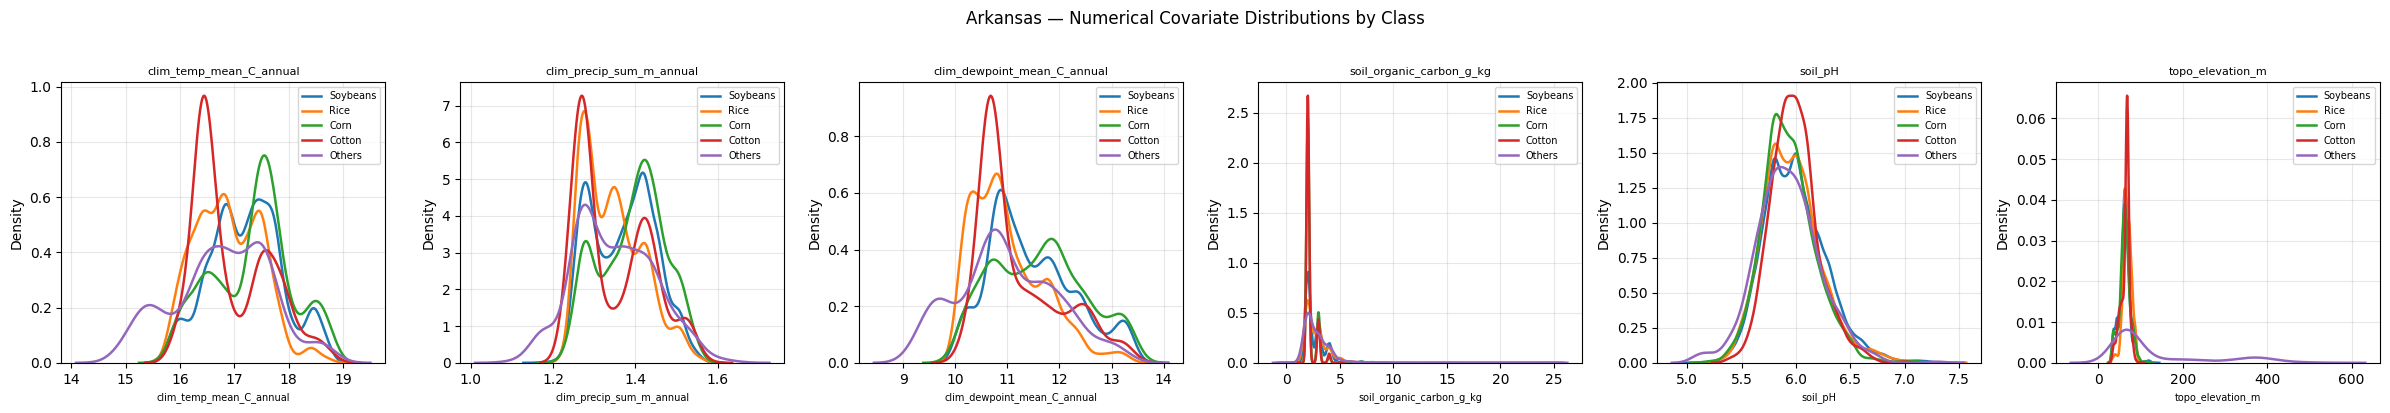

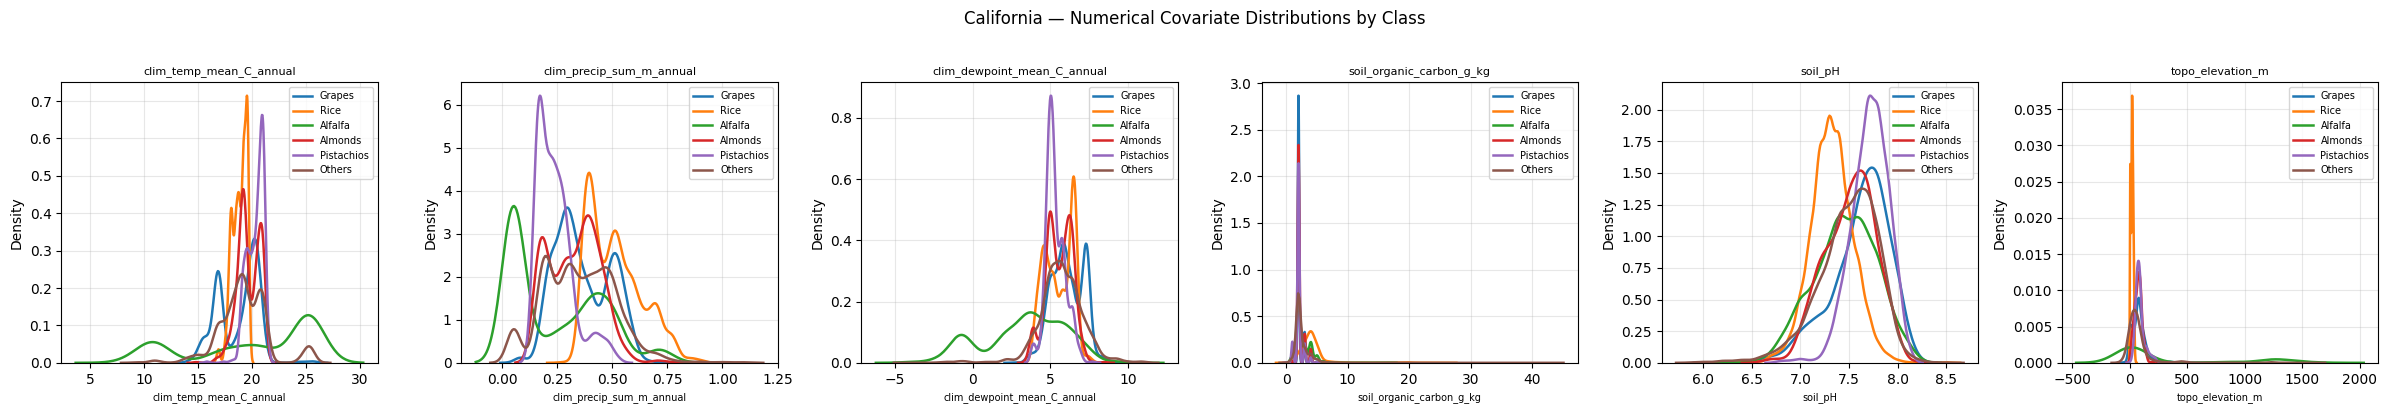

In [ ]:
def plot_covar_distributions(df, label_map, covar_cols, title_prefix):
    """KDE plots of each numerical covariate, one curve per crop class."""
    n = len(covar_cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    palette = sns.color_palette('tab10', len(label_map))
    for ax, col in zip(axes, covar_cols):
        for (code_lbl, name), color in zip(label_map.items(), palette):
            subset = df.loc[df['label'] == code_lbl, col].dropna()
            sns.kdeplot(subset, ax=ax, label=name, color=color, linewidth=1.8)
        ax.set_title(col, fontsize=8)
        ax.set_xlabel(col, fontsize=7)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
    fig.suptitle(f'{title_prefix} — Numerical Covariate Distributions by Class', y=1.02)
    plt.tight_layout()
    plt.show()


plot_covar_distributions(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, 'Arkansas')
plot_covar_distributions(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, 'California')


### 2.2 Boxplots of Numerical Covariates per Class

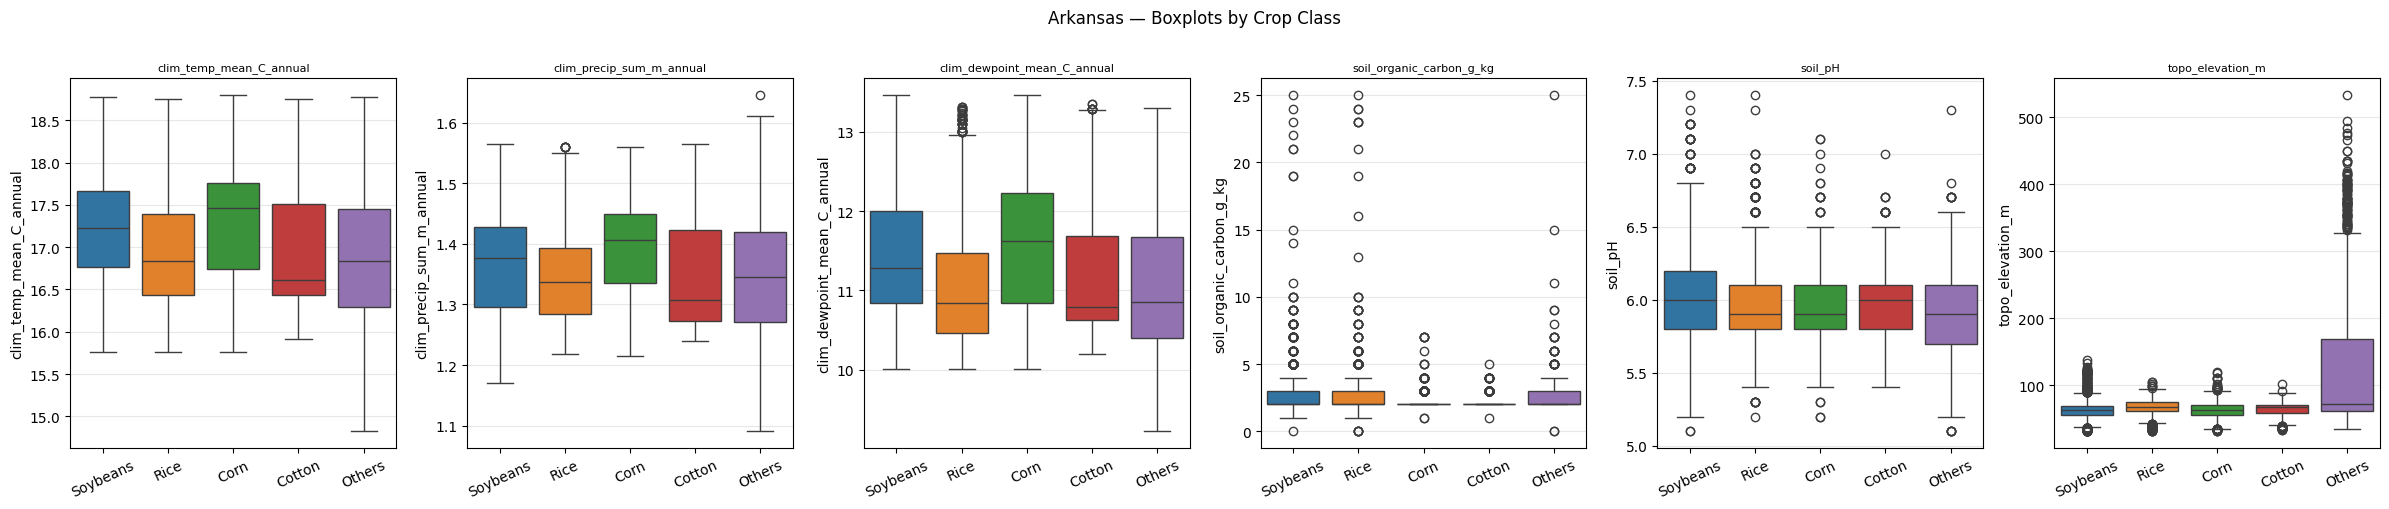

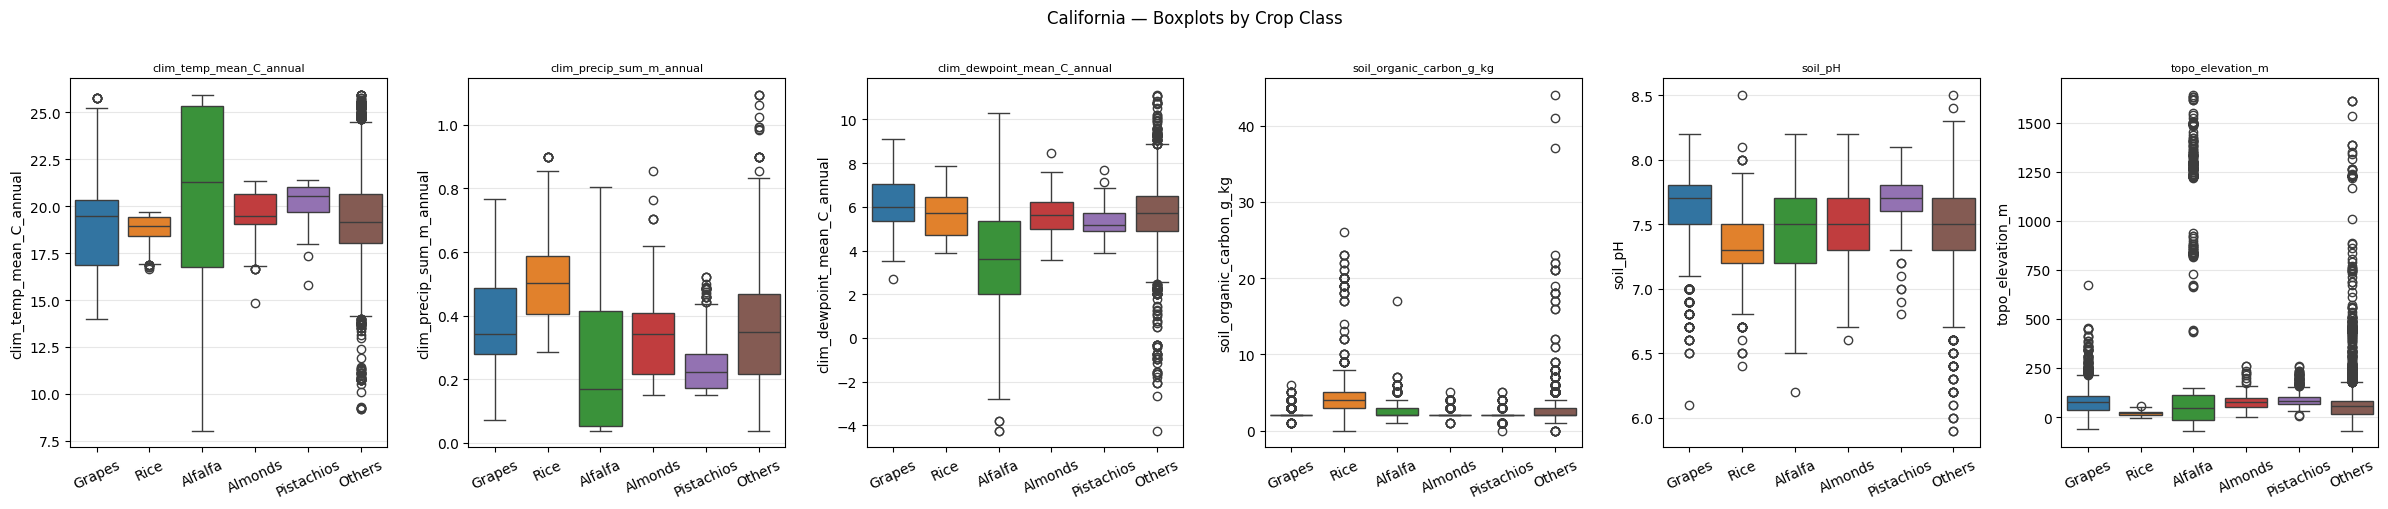

In [11]:
def plot_covar_boxplots(df, label_map, covar_cols, title_prefix):
    """Box-plots of numerical covariates split by crop class."""
    df_plot = df.copy()
    df_plot['crop'] = df_plot['label'].map(label_map)
    n = len(covar_cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, covar_cols):
        order = [label_map[k] for k in sorted(label_map)]
        sns.boxplot(data=df_plot, x='crop', y=col, order=order,
                    palette='tab10', ax=ax)
        ax.set_title(col, fontsize=8)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=25)
        ax.grid(alpha=0.3, axis='y')
    fig.suptitle(f'{title_prefix} — Boxplots by Crop Class', y=1.01)
    plt.tight_layout()
    plt.show()

plot_covar_boxplots(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, 'Arkansas')
plot_covar_boxplots(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, 'California')


### 2.3 Categorical Covariate Distributions per Class

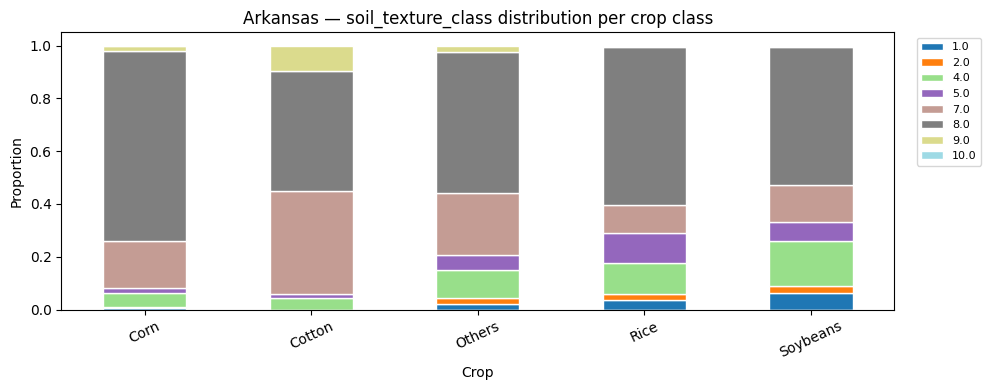

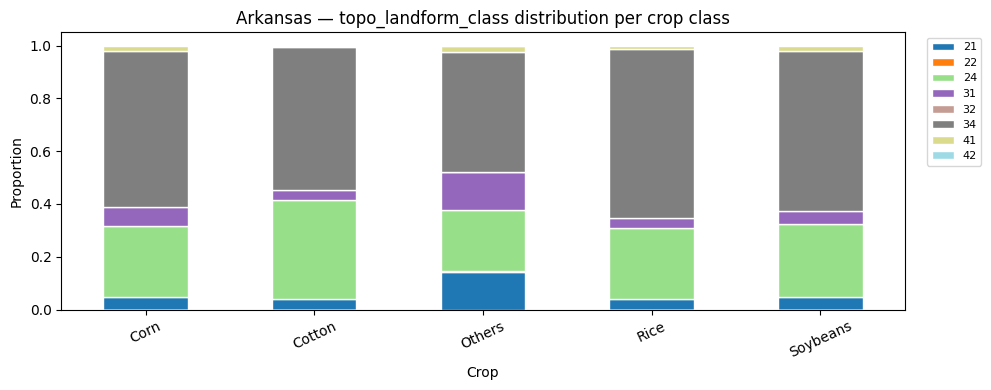

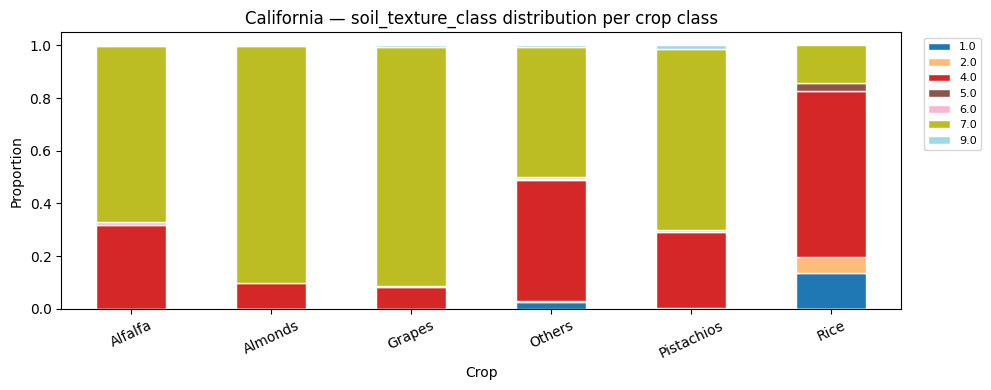

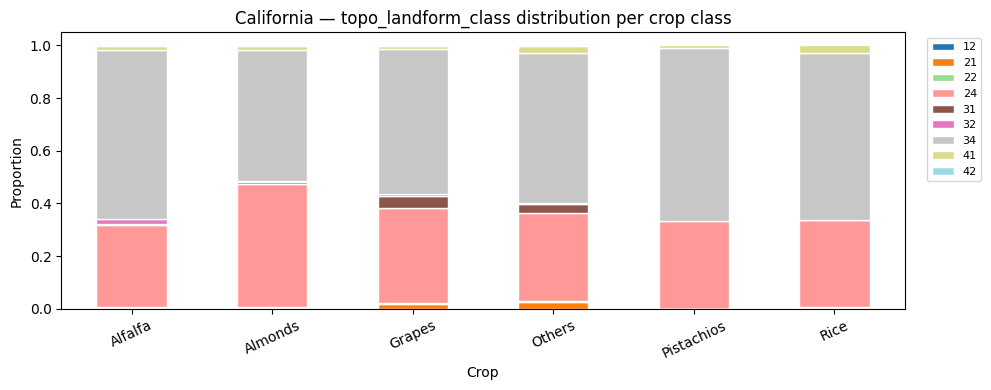

In [12]:
def plot_cat_distributions(df, label_map, cat_cols, title_prefix):
    """Stacked bar charts for categorical covariates split by class."""
    df_plot = df.copy()
    df_plot['crop'] = df_plot['label'].map(label_map)
    for col in cat_cols:
        cross = pd.crosstab(df_plot['crop'], df_plot[col], normalize='index')
        cross.plot(kind='bar', stacked=True, figsize=(10, 4),
                   colormap='tab20', edgecolor='white')
        plt.title(f'{title_prefix} — {col} distribution per crop class')
        plt.ylabel('Proportion')
        plt.xlabel('Crop')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

plot_cat_distributions(df_ar, AR_LABELS, COVAR_CAT, 'Arkansas')
plot_cat_distributions(df_ca, CA_LABELS, COVAR_CAT, 'California')


### 2.4 Correlation Heatmap — Numerical Covariates

Arkansas:


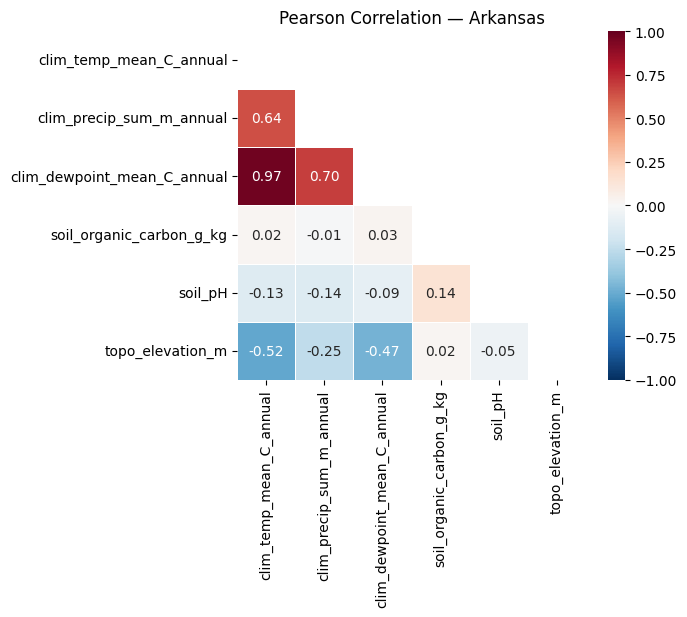

California:


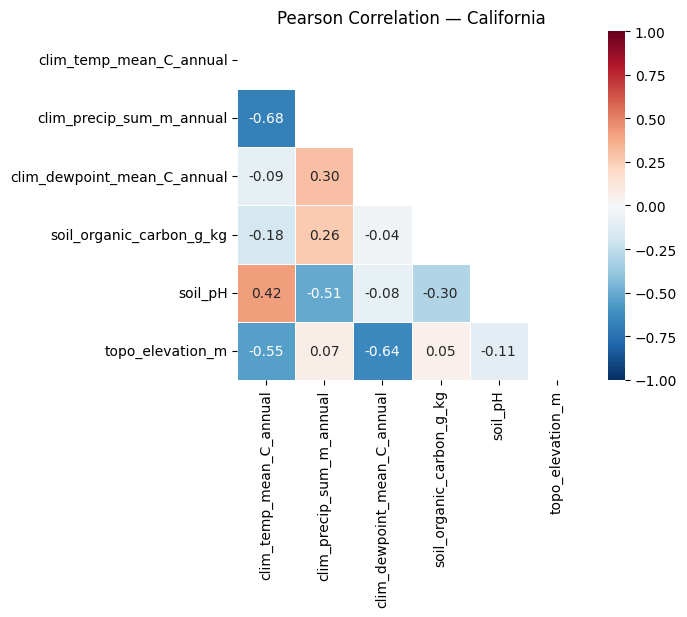

In [13]:
def plot_correlation_heatmap(df, covar_cols, title):
    """Pearson correlation among numerical covariates."""
    corr = df[covar_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, square=True, ax=ax, linewidths=0.5)
    ax.set_title(f'Pearson Correlation — {title}')
    plt.tight_layout()
    plt.show()
    return corr

print('Arkansas:')
corr_ar = plot_correlation_heatmap(df_ar, COVAR_DISPLAY_NUM, 'Arkansas')
print('California:')
corr_ca = plot_correlation_heatmap(df_ca, COVAR_DISPLAY_NUM, 'California')


### 2.5 Covariate–Class Association

In [ ]:
from scipy.stats import pointbiserialr, f_oneway

def covariate_class_association(df, label_map, covar_num, covar_cat, title):
    """
    For numerical covariates: one-way ANOVA F-statistic across classes.
    For categorical covariates: Cramér's V (chi-squared based).
    """
    print(f'\n===== {title} =====')
    print('\nNumerical covariates (ANOVA F-statistic, p-value):')
    for col in covar_num:
        groups = [df.loc[df['label'] == c, col].dropna().values for c in sorted(label_map)]
        F, p = f_oneway(*groups)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {col:40s}  F={F:9.2f}  p={p:.2e}  {sig}')
    print('\nCategorical covariates (Cramér\'s V):')
    for col in covar_cat:
        from scipy.stats import chi2_contingency
        ct = pd.crosstab(df['label'], df[col])
        chi2_val, p_val, dof, _ = chi2_contingency(ct)
        n = ct.values.sum()
        k = min(ct.shape) - 1
        v = np.sqrt(chi2_val / (n * k)) if k > 0 else 0
        print(f'  {col:40s}  V={v:.4f}  chi2={chi2_val:.2f}  p={p_val:.2e}')


covariate_class_association(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, COVAR_CAT, 'Arkansas')
covariate_class_association(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, COVAR_CAT, 'California')



===== Arkansas =====

Numerical covariates (ANOVA F-statistic, p-value):
  clim_temp_mean_C_annual                   F=   180.90  p=6.69e-150  ***
  clim_precip_sum_m_annual                  F=   111.68  p=2.72e-93  ***
  clim_dewpoint_mean_C_annual               F=   209.23  p=1.15e-172  ***
  soil_organic_carbon_g_kg                  F=    80.19  p=4.35e-67  ***
  soil_pH                                   F=    19.53  p=5.08e-16  ***
  topo_elevation_m                          F=   721.90  p=0.00e+00  ***

Categorical covariates (Cramér's V):
  soil_texture_class                        V=0.1841  chi2=1356.09  p=3.55e-268
  topo_landform_class                       V=0.0959  chi2=367.77  p=6.55e-61

===== California =====

Numerical covariates (ANOVA F-statistic, p-value):
  clim_temp_mean_C_annual                   F=    75.65  p=4.53e-78  ***
  clim_precip_sum_m_annual                  F=   637.37  p=0.00e+00  ***
  clim_dewpoint_mean_C_annual               F=   574.45  p=0.00e+00 

### 2.6 Pairwise Scatter Matrix — Numerical Covariates (Arkansas)

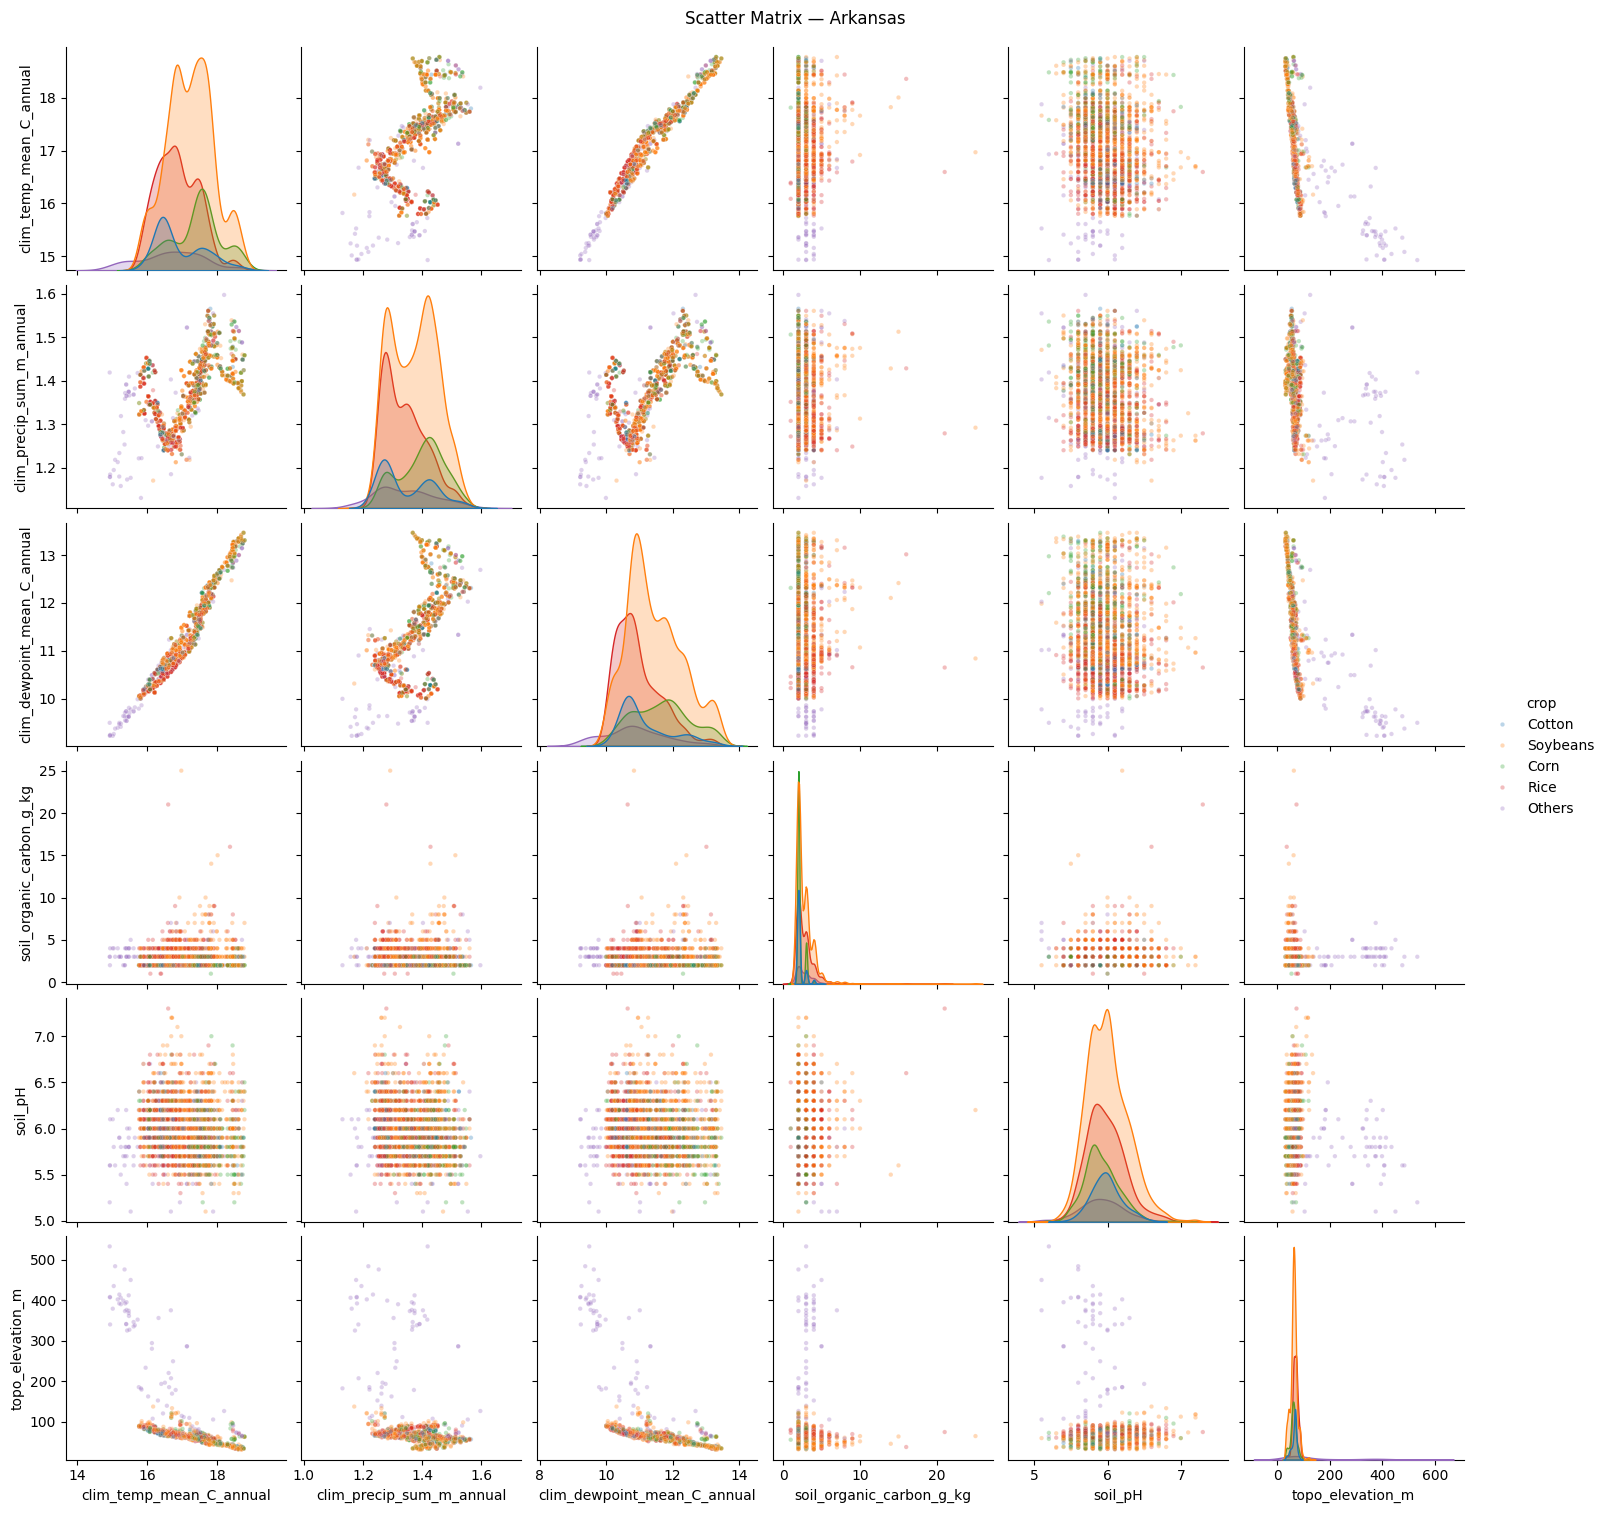

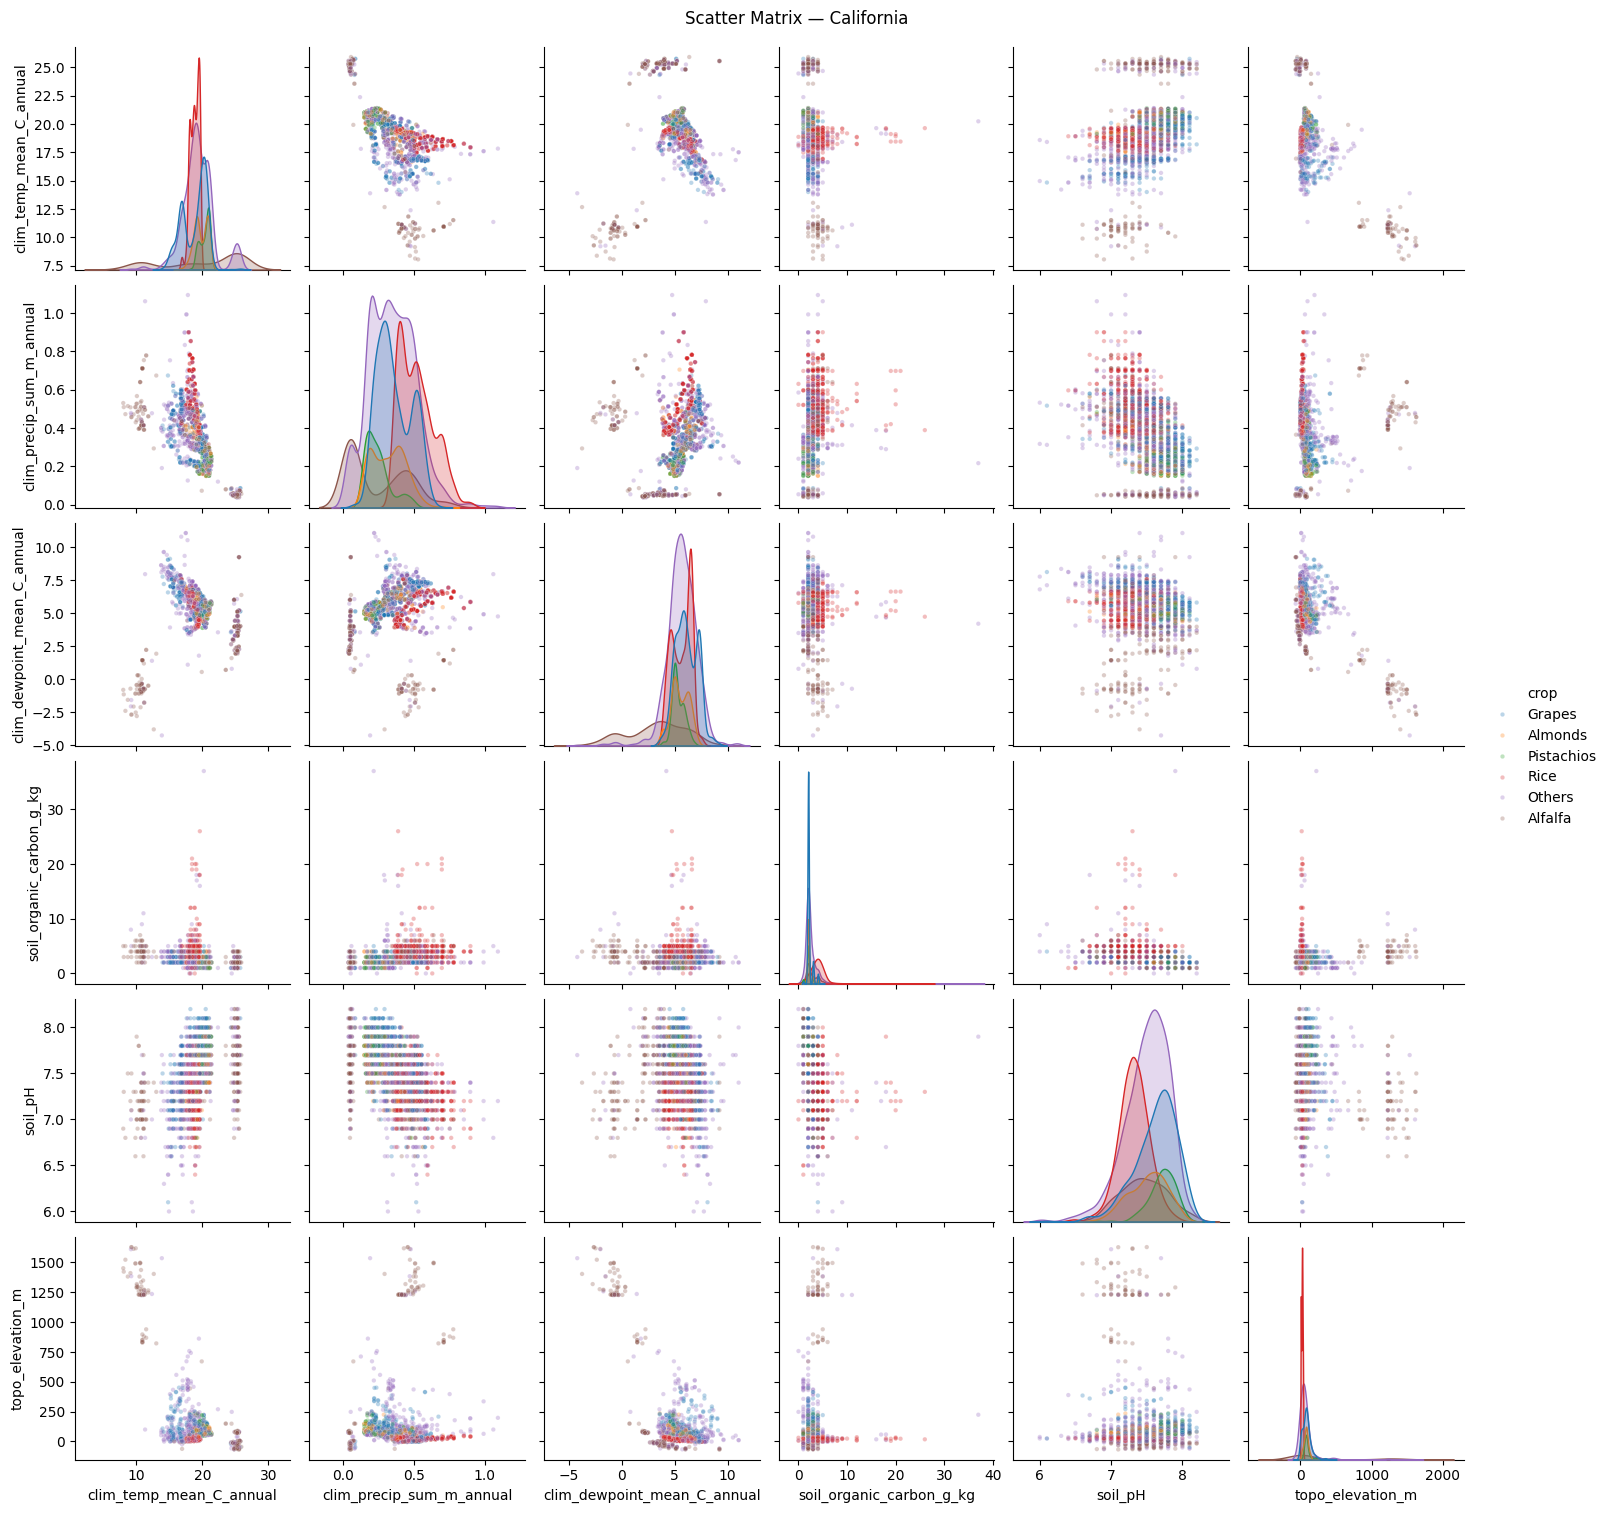

In [15]:
def plot_scatter_matrix(df, label_map, covar_cols, title, max_samples=3000):
    """Seaborn pairplot for a random subsample, coloured by crop class."""
    df_plot = df.sample(min(max_samples, len(df)), random_state=SEED).copy()
    df_plot['crop'] = df_plot['label'].map(label_map)
    g = sns.pairplot(df_plot[covar_cols + ['crop']],
                     hue='crop', diag_kind='kde',
                     plot_kws={'alpha': 0.3, 's': 10},
                     palette='tab10')
    g.fig.suptitle(f'Scatter Matrix — {title}', y=1.01, fontsize=12)
    plt.show()

plot_scatter_matrix(df_ar, AR_LABELS, COVAR_DISPLAY_NUM, 'Arkansas')
plot_scatter_matrix(df_ca, CA_LABELS, COVAR_DISPLAY_NUM, 'California')


# Part 3 -- Ablation Study

### 3.1 Ablation Helper Functions

In [16]:
def get_covar_indices(encoder, covar_subset):
    """
    Given a ColumnTransformer and a list of covariate names,
    return the column indices in the transformed feature array.
    """
    # Numerical transformer comes first
    num_features = encoder.named_transformers_['num'].feature_names_in_.tolist()
    cat_features = encoder.named_transformers_['cat'].feature_names_in_.tolist()
    n_num = len(num_features)
    n_cat_encoded = encoder.named_transformers_['cat'].categories_
    n_cat_total   = sum(len(c) for c in n_cat_encoded)

    indices = []
    col_ptr = 0

    # Numerical indices
    for i, feat in enumerate(num_features):
        if feat in covar_subset:
            indices.append(i)
    col_ptr = n_num

    # Categorical one-hot indices
    for feat, cats in zip(cat_features, n_cat_encoded):
        for j in range(len(cats)):
            if feat in covar_subset:
                indices.append(col_ptr + j)
        col_ptr += len(cats)

    return sorted(indices)


def get_group_sizes(encoder, covar_subset):
    """
    Return encoded column counts per covariate group present in covar_subset.
    Groups are always ordered: [Climate, Soil, Topography].
    Returns (group_sizes_list, group_labels_list), or (None, labels) if <=1 group.
    """
    if not covar_subset:
        return None, []

    GROUPS_ORDERED = [
        ('Climate',    CLIM_COLS),
        ('Soil',       SOIL_COLS),
        ('Topography', TOPO_COLS),
    ]

    num_features = encoder.named_transformers_['num'].feature_names_in_.tolist()
    cat_features = encoder.named_transformers_['cat'].feature_names_in_.tolist()
    cat_sizes    = [len(c) for c in encoder.named_transformers_['cat'].categories_]

    group_sizes  = []
    group_labels = []
    for grp_name, grp_cols in GROUPS_ORDERED:
        subset_in_group = [c for c in grp_cols if c in covar_subset]
        if not subset_in_group:
            continue
        size = 0
        for col in subset_in_group:
            if col in num_features:
                size += 1
            elif col in cat_features:
                size += cat_sizes[cat_features.index(col)]
        group_sizes.append(size)
        group_labels.append(grp_name)

    if len(group_sizes) <= 1:
        return None, group_labels
    return group_sizes, group_labels


def make_ablation_split(full_split, col_indices):
    """
    Slice covariate array to only the requested columns.
    full_split: tuple (X, mask, C_all, y)
    Returns: (X, mask, C_sub, y)
    """
    X, mask, C_all, y = full_split
    C_sub = C_all[:, col_indices] if col_indices else None
    return X, mask, C_sub, y


# Define the 5 ablation configurations
ABLATION_CONFIGS = {
    'S2 only'        : [],           # baseline — spectral only
    'S2 + Climate'   : CLIM_COLS,    # CLIM_COLS  # 108 temporal climate cols (3 bands × 36 steps)
    'S2 + Soil'      : SOIL_COLS,    # ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
    'S2 + Topography': TOPO_COLS,    # ['topo_elevation_m', 'topo_landform_class']
    'S2 + All'       : ALL_COVARS,   # all 8 covariates
}

print('Ablation configurations:')
for name, cols in ABLATION_CONFIGS.items():
    n = len(cols) if cols else 0
    print(f'  {name:20s}: {n} covariate columns  {cols if cols else ""}')

Ablation configurations:
  S2 only             : 0 covariate columns  
  S2 + Climate        : 108 covariate columns  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03', 'clim_temp_mean_C_t04', 'clim_temp_mean_C_t05', 'clim_temp_mean_C_t06', 'clim_temp_mean_C_t07', 'clim_temp_mean_C_t08', 'clim_temp_mean_C_t09', 'clim_temp_mean_C_t10', 'clim_temp_mean_C_t11', 'clim_temp_mean_C_t12', 'clim_temp_mean_C_t13', 'clim_temp_mean_C_t14', 'clim_temp_mean_C_t15', 'clim_temp_mean_C_t16', 'clim_temp_mean_C_t17', 'clim_temp_mean_C_t18', 'clim_temp_mean_C_t19', 'clim_temp_mean_C_t20', 'clim_temp_mean_C_t21', 'clim_temp_mean_C_t22', 'clim_temp_mean_C_t23', 'clim_temp_mean_C_t24', 'clim_temp_mean_C_t25', 'clim_temp_mean_C_t26', 'clim_temp_mean_C_t27', 'clim_temp_mean_C_t28', 'clim_temp_mean_C_t29', 'clim_temp_mean_C_t30', 'clim_temp_mean_C_t31', 'clim_temp_mean_C_t32', 'clim_temp_mean_C_t33', 'clim_temp_mean_C_t34', 'clim_temp_mean_C_t35', 'clim_temp_mean_C_t36', 'clim_precip_sum_

### 3.2 Run Ablation

In [ ]:
def run_ablation(state, label_map, class_names,
                 full_train, full_val, full_test,
                 covar_encoder, configs,
                 epochs=200, batch_size=32):
    """
    Train MCTNet under each configuration in `configs` and collect metrics.
    Plots loss and accuracy curves after each configuration.
    Returns a DataFrame with OA, Kappa, F1 per configuration.

    KEY FIX: reset_seeds() + clear_session() before every model build ensures
    reproducible OA values and eliminates the Part 1 / Part 3 discrepancy.
    """
    n_classes = len(label_map)
    records   = []

    all_histories = {}

    for cfg_name, covar_cols in configs.items():
        print(f'\n{"="*60}')
        print(f'State: {state}  |  Config: {cfg_name}')
        n_cols = len(covar_cols) if covar_cols else 0
        print(f'Covariates used: {n_cols} columns  {covar_cols[:3] if covar_cols else "none"}'
              f'{" …" if n_cols > 3 else ""}')
        print('='*60)
        # reset all random seeds before each build+train 
        reset_seeds()
        tf.keras.backend.clear_session()

        if covar_cols:
            idx   = get_covar_indices(covar_encoder, covar_cols)
            n_cov = len(idx)
            tr    = make_ablation_split(full_train, idx)
            va    = make_ablation_split(full_val,   idx)
            te    = make_ablation_split(full_test,  idx)

            g_sizes, g_labels = get_group_sizes(covar_encoder, covar_cols)
            if g_sizes is not None:
                print(f'  Per-group gating: {list(zip(g_labels, g_sizes))}')
                assert sum(g_sizes) == n_cov, f'Group size mismatch: {sum(g_sizes)} != {n_cov}'
            else:
                print(f'  Single-gate mode (one group: {g_labels})')

            # Asymmetric gate biases (signal-strength-aware)
            # Climate  → -2.0 (sigmoid≈0.119): high signal, opens freely
            # Soil     → -3.0 (sigmoid≈0.047): moderate signal, earns contribution
            # Topo     → -3.0 (sigmoid≈0.047): mixed/noisy signal, stays gated
            _GROUP_GATE_BIAS = {'Climate': -2.0, 'Soil': -3.0, 'Topography': -3.0}
            if g_sizes is not None:
                # Per-group mode (S2+All): individual bias per group
                gate_biases = [
                    keras.initializers.Constant(_GROUP_GATE_BIAS.get(lbl, -3.0))
                    for lbl in g_labels
                ]
            elif g_labels and g_labels[0] == 'Topography':
                # Topography-only single gate: tight bias prevents CA noise leak
                gate_biases = -3.0
            else:
                # Climate-only or Soil-only: default single-gate bias (-2.0)
                gate_biases = None

            model = build_mctnet_with_covariates(n_classes, n_cov,
                                                  group_sizes=g_sizes,
                                                  gate_biases=gate_biases)
        else:
            tr    = (full_train[0], full_train[1], full_train[3])
            va    = (full_val[0],   full_val[1],   full_val[3])
            te    = (full_test[0],  full_test[1],  full_test[3])
            model = build_mctnet(n_classes)
            g_labels = None

        print(f'Parameters: {model.count_params():,}')
        history = train_model(model, tr, va, epochs=epochs, batch_size=batch_size)
        all_histories[cfg_name] = history

        plot_history(history, f'{state} — {cfg_name}')

        oa, kappa, f1 = evaluate_test(model, te, class_names, f'{state} — {cfg_name}')

        safe_cfg = cfg_name.replace(' ', '_').replace('+', 'plus').replace('/', '_').lower()
        model_filename = f'mctnet_{state.lower()}_{safe_cfg}.keras'
        model_save_path = os.path.join(FOLDER, model_filename)
        model.save(model_save_path)
        print(f'  ✓ Model saved → {model_filename}')

        if covar_cols:
            print_gate_diagnostics(model, te, group_names=g_labels)

        records.append({
            'Config'  : cfg_name,
            'OA'      : round(oa,    4),
            'Kappa'   : round(kappa, 4),
            'F1-macro': round(f1,    4),
            'Params'  : model.count_params(),
        })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_histories)))
    for (cfg_name, hist), color in zip(all_histories.items(), colors):
        axes[0].plot(hist.history['val_loss'],     label=cfg_name, color=color, linewidth=1.6)
        axes[1].plot(hist.history['val_accuracy'], label=cfg_name, color=color, linewidth=1.6)
    for ax, ylabel, title in zip(
        axes,
        ['Validation Loss', 'Validation Accuracy'],
        [f'{state} — Val Loss (all configs)', f'{state} — Val Accuracy (all configs)']
    ):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(records)

print('Ablation runner ready.')


Ablation runner ready.


### 3.3 Arkansas Ablation


State: Arkansas  |  Config: S2 only
Covariates used: 0 columns  none
Parameters: 29,489
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 481ms/step - accuracy: 0.4467 - loss: 1.7244 - val_accuracy: 0.3133 - val_loss: 1.9282 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7950 - loss: 0.7839 - val_accuracy: 0.3667 - val_loss: 1.9043 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.5776 - val_accuracy: 0.4167 - val_loss: 1.8480 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9175 - loss: 0.4793 - val_accuracy: 0.4133 - val_loss: 1.8430 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9450 - loss: 0.4150 - val_accuracy: 0.4500 - val_loss: 1.7348 - learning_rate: 0.0010
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9600 - loss: 0.3733 - val_accuracy: 0.4767 - val_loss: 1.5909 - learning_rate: 0.001

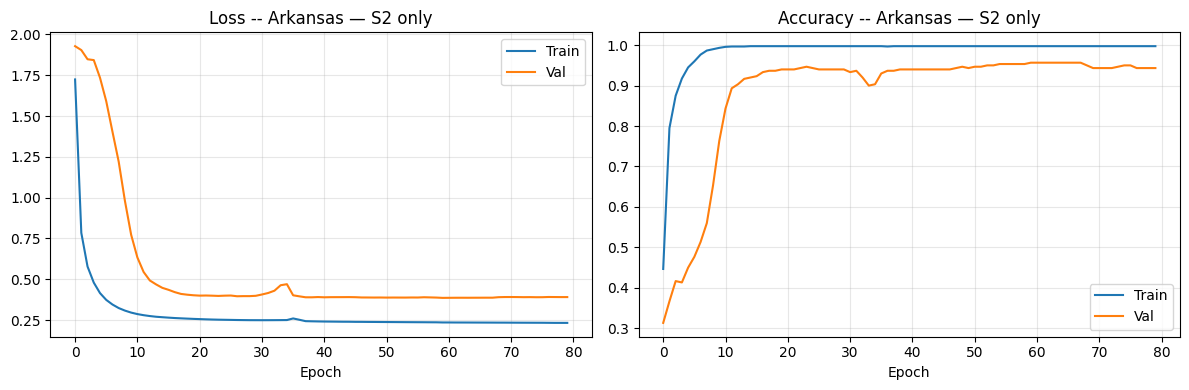


--- Arkansas — S2 only Test Results ---
OA=0.9399  Kappa=0.9095  F1=0.8906
              precision    recall  f1-score   support

    Soybeans       0.99      0.91      0.95      4404
        Rice       0.99      0.98      0.99      2188
        Corn       0.92      0.98      0.95      1092
      Cotton       0.89      0.96      0.92       506
      Others       0.50      0.94      0.65       310

    accuracy                           0.94      8500
   macro avg       0.86      0.95      0.89      8500
weighted avg       0.96      0.94      0.94      8500



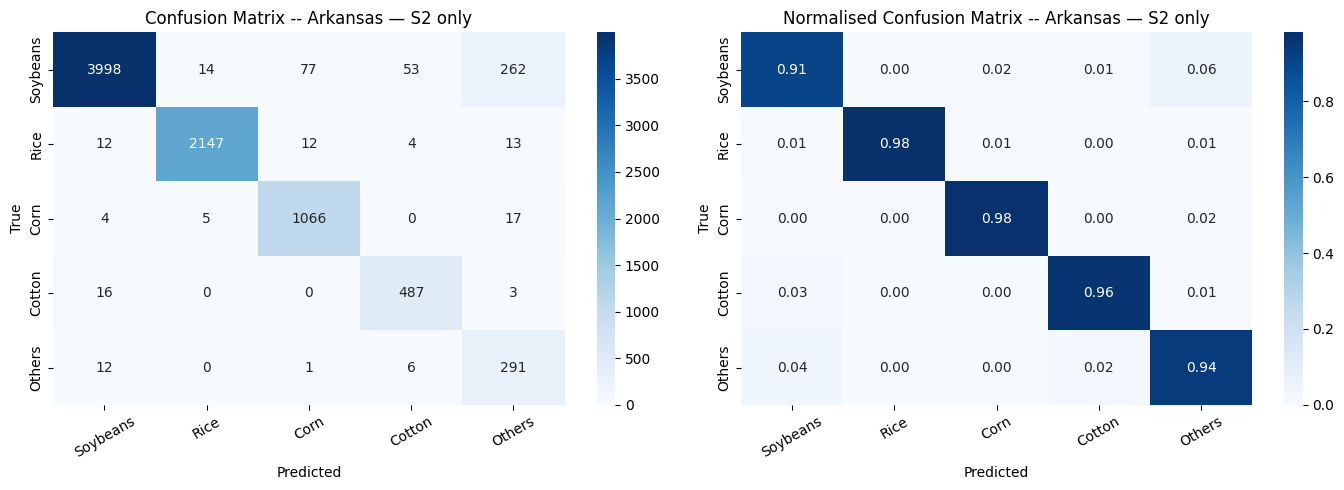

  ✓ Model saved → mctnet_arkansas_s2_only.keras

State: Arkansas  |  Config: S2 + Climate
Covariates used: 108 columns  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] …
  Single-gate mode (one group: ['Climate'])
Parameters: 38,814
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 502ms/step - accuracy: 0.4833 - loss: 1.5990 - val_accuracy: 0.4100 - val_loss: 1.6026 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8208 - loss: 0.8549 - val_accuracy: 0.2900 - val_loss: 1.7396 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8858 - loss: 0.6340 - val_accuracy: 0.3400 - val_loss: 1.8379 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9283 - loss: 0.5273 - val_accuracy: 0.3700 - val_loss: 1.7841 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9475 - loss: 0.4628 - val_accuracy: 0.3767 - val_loss: 1.6486 - lea

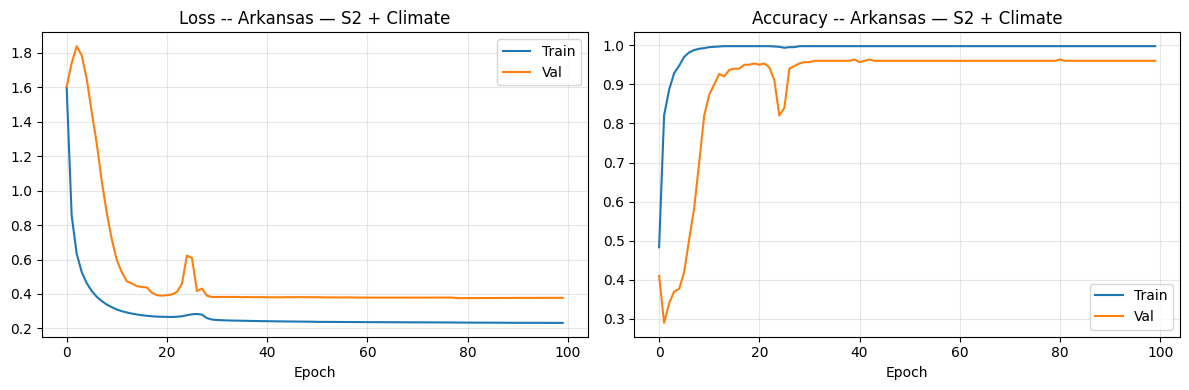


--- Arkansas — S2 + Climate Test Results ---
OA=0.9431  Kappa=0.9141  F1=0.8933
              precision    recall  f1-score   support

    Soybeans       0.99      0.91      0.95      4404
        Rice       0.99      0.99      0.99      2188
        Corn       0.93      0.98      0.95      1092
      Cotton       0.87      0.96      0.91       506
      Others       0.52      0.92      0.66       310

    accuracy                           0.94      8500
   macro avg       0.86      0.95      0.89      8500
weighted avg       0.96      0.94      0.95      8500



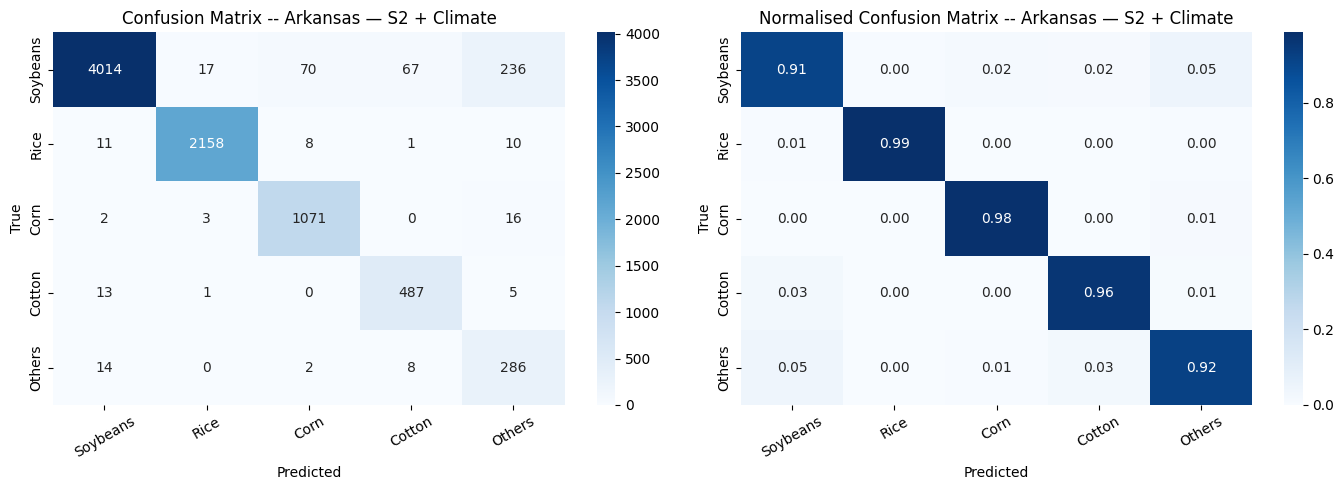

  ✓ Model saved → mctnet_arkansas_s2_plus_climate.keras

  Gate Values (mean over test set):
  Climate        : 0.376 +/- 0.391  |#######


State: Arkansas  |  Config: S2 + Soil
Covariates used: 3 columns  ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
  Single-gate mode (one group: ['Soil'])
Parameters: 32,379
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 440ms/step - accuracy: 0.4808 - loss: 1.5493 - val_accuracy: 0.3533 - val_loss: 1.5959 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8208 - loss: 0.8005 - val_accuracy: 0.2633 - val_loss: 1.7505 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8825 - loss: 0.5898 - val_accuracy: 0.2900 - val_loss: 1.8427 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9167 - loss: 0.4894 - val_accuracy: 0.3667 - val_loss: 1.8040 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy

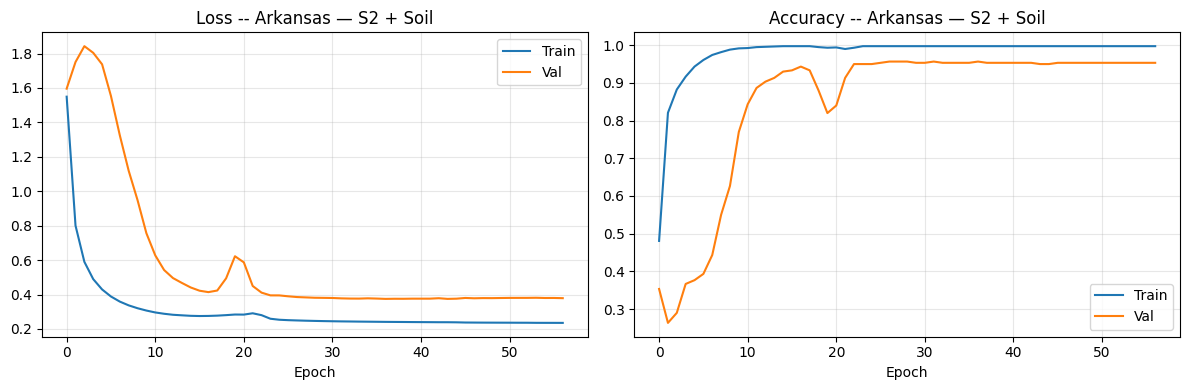


--- Arkansas — S2 + Soil Test Results ---
OA=0.9474  Kappa=0.9204  F1=0.9052
              precision    recall  f1-score   support

    Soybeans       0.99      0.92      0.95      4404
        Rice       0.98      0.98      0.98      2188
        Corn       0.90      0.98      0.94      1092
      Cotton       0.87      0.96      0.92       506
      Others       0.60      0.93      0.73       310

    accuracy                           0.95      8500
   macro avg       0.87      0.96      0.91      8500
weighted avg       0.96      0.95      0.95      8500



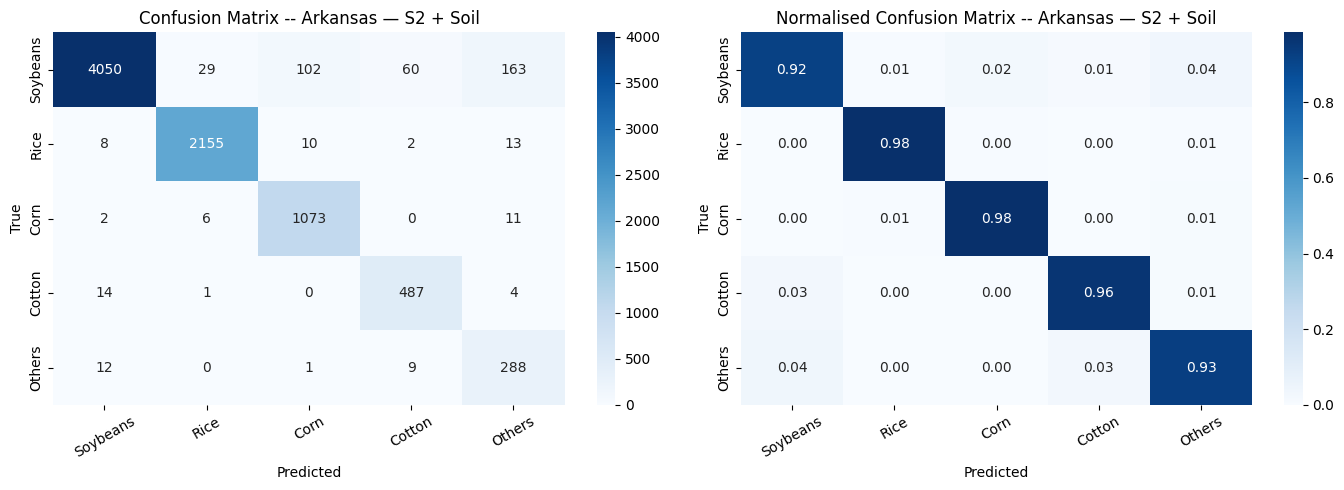

  ✓ Model saved → mctnet_arkansas_s2_plus_soil.keras

  Gate Values (mean over test set):
  Soil           : 0.138 +/- 0.066  |##


State: Arkansas  |  Config: S2 + Topography
Covariates used: 2 columns  ['topo_elevation_m', 'topo_landform_class']
  Single-gate mode (one group: ['Topography'])
Parameters: 32,379
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 451ms/step - accuracy: 0.4750 - loss: 1.5506 - val_accuracy: 0.3533 - val_loss: 1.5823 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8058 - loss: 0.7986 - val_accuracy: 0.2733 - val_loss: 1.6886 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8775 - loss: 0.5827 - val_accuracy: 0.3300 - val_loss: 1.8194 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9150 - loss: 0.4840 - val_accuracy: 0.3667 - val_loss: 1.8257 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - los

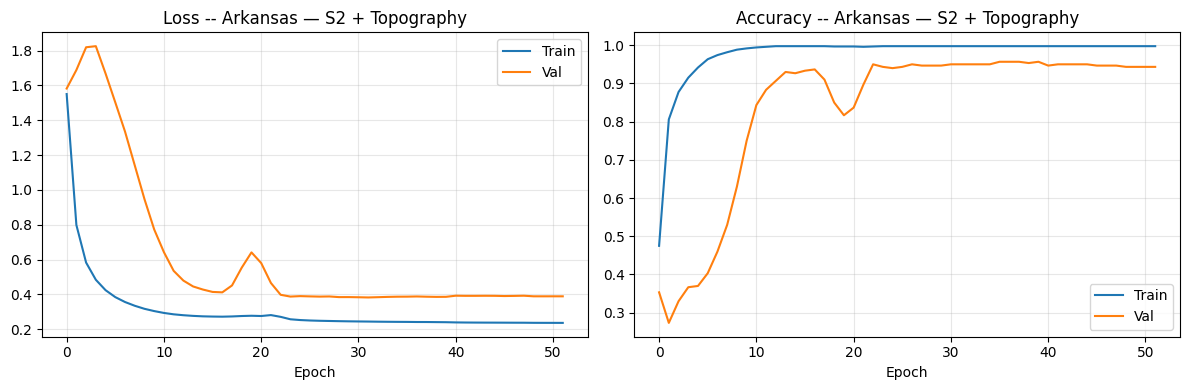


--- Arkansas — S2 + Topography Test Results ---
OA=0.9539  Kappa=0.9298  F1=0.9106
              precision    recall  f1-score   support

    Soybeans       0.99      0.93      0.96      4404
        Rice       0.99      0.99      0.99      2188
        Corn       0.94      0.98      0.96      1092
      Cotton       0.86      0.96      0.91       506
      Others       0.63      0.90      0.74       310

    accuracy                           0.95      8500
   macro avg       0.88      0.95      0.91      8500
weighted avg       0.96      0.95      0.96      8500



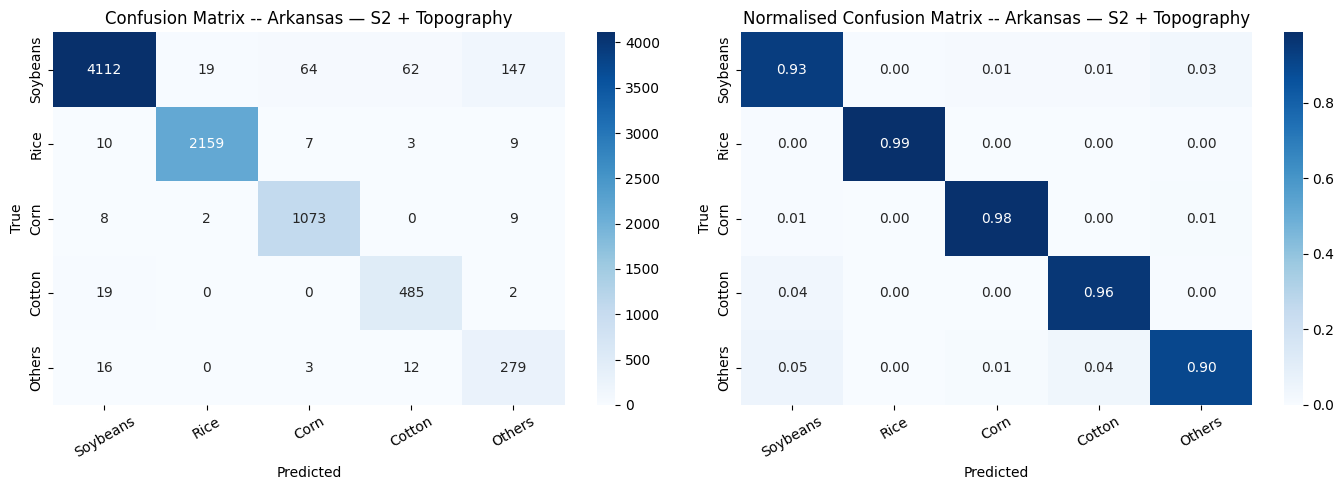

  ✓ Model saved → mctnet_arkansas_s2_plus_topography.keras

  Gate Values (mean over test set):
  Topography     : 0.061 +/- 0.017  |#


State: Arkansas  |  Config: S2 + All
Covariates used: 113 columns  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] …
  Per-group gating: [('Climate', 108), ('Soil', 9), ('Topography', 9)]
Parameters: 33,491
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 52s 561ms/step - accuracy: 0.5225 - loss: 1.3970 - val_accuracy: 0.2633 - val_loss: 1.8832 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8092 - loss: 0.8077 - val_accuracy: 0.3067 - val_loss: 2.0534 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8883 - loss: 0.6255 - val_accuracy: 0.3500 - val_loss: 1.9537 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9150 - loss: 0.5295 - val_accuracy: 0.3167 - val_loss: 2.0190 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━

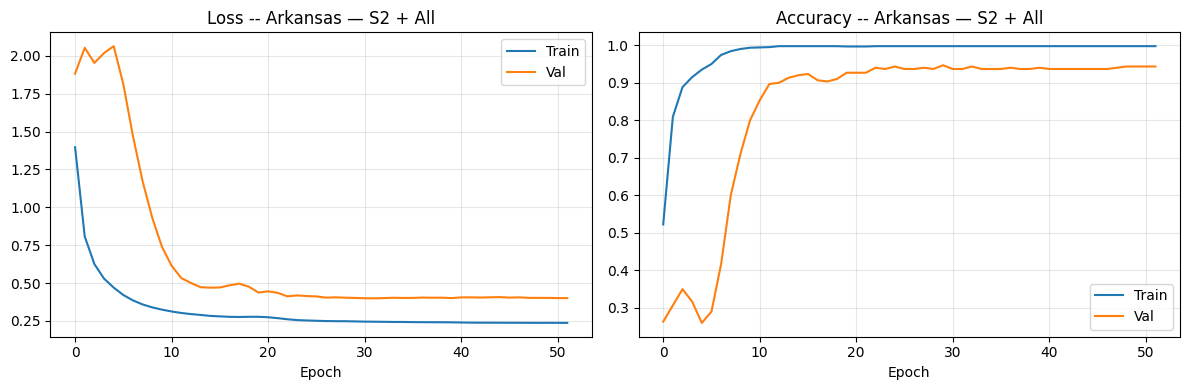


--- Arkansas — S2 + All Test Results ---
OA=0.9522  Kappa=0.9273  F1=0.9076
              precision    recall  f1-score   support

    Soybeans       0.99      0.93      0.96      4404
        Rice       0.99      0.99      0.99      2188
        Corn       0.95      0.97      0.96      1092
      Cotton       0.85      0.96      0.90       506
      Others       0.60      0.92      0.73       310

    accuracy                           0.95      8500
   macro avg       0.88      0.95      0.91      8500
weighted avg       0.96      0.95      0.95      8500



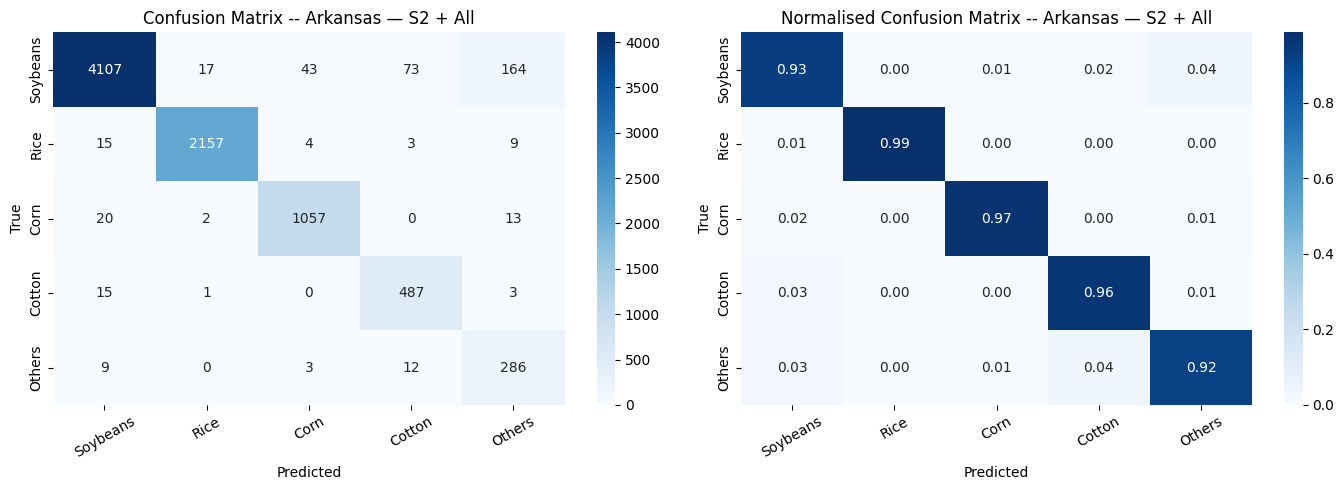

  ✓ Model saved → mctnet_arkansas_s2_plus_all.keras

  Gate Values (mean over test set):
  Climate        : 0.157 +/- 0.202  |###
  Soil           : 0.078 +/- 0.034  |#
  Topography     : 0.045 +/- 0.008  |



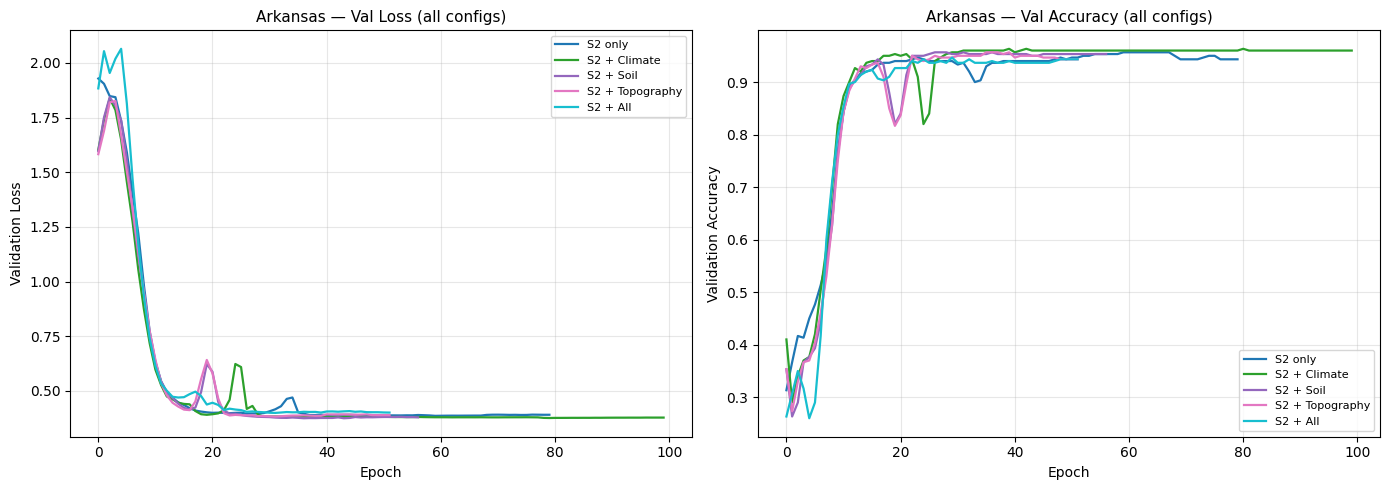


===== Arkansas Ablation Results =====
         Config     OA  Kappa  F1-macro  Params
        S2 only 0.9399 0.9095    0.8906   29489
   S2 + Climate 0.9431 0.9141    0.8933   38814
      S2 + Soil 0.9474 0.9204    0.9052   32379
S2 + Topography 0.9539 0.9298    0.9106   32379
       S2 + All 0.9522 0.9273    0.9076   33491


In [18]:
ablation_ar = run_ablation(
    state         = 'Arkansas',
    label_map     = AR_LABELS,
    class_names   = ar_classes,
    full_train    = ar_train,
    full_val      = ar_val,
    full_test     = ar_test,
    covar_encoder = ar_enc,
    configs       = ABLATION_CONFIGS,
)
print('\n===== Arkansas Ablation Results =====')
print(ablation_ar.to_string(index=False))


### 3.4 California Ablation


State: California  |  Config: S2 only
Covariates used: 0 columns  none
Parameters: 29,570
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - accuracy: 0.4799 - loss: 1.6354 - val_accuracy: 0.1944 - val_loss: 1.8043 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7340 - loss: 0.8792 - val_accuracy: 0.2028 - val_loss: 1.7323 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8007 - loss: 0.7693 - val_accuracy: 0.1833 - val_loss: 1.8039 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8333 - loss: 0.7031 - val_accuracy: 0.1750 - val_loss: 1.9164 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8472 - loss: 0.6521 - val_accuracy: 0.1944 - val_loss: 1.8561 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8618 - loss: 0.6146 - val_accuracy: 0.2444 - val_loss: 1.7429 - learning_rate: 0.

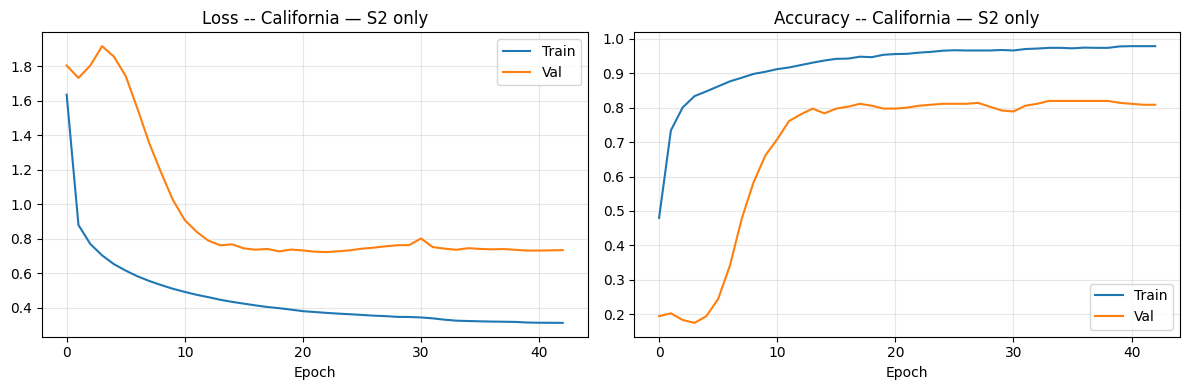


--- California — S2 only Test Results ---
OA=0.7887  Kappa=0.7267  F1=0.7347
              precision    recall  f1-score   support

      Grapes       0.84      0.71      0.77      1708
        Rice       0.97      0.98      0.98      1556
     Alfalfa       0.73      0.94      0.82       685
     Almonds       0.43      0.75      0.54       508
  Pistachios       0.33      0.93      0.49       285
      Others       0.93      0.70      0.80      3458

    accuracy                           0.79      8200
   macro avg       0.71      0.84      0.73      8200
weighted avg       0.85      0.79      0.80      8200



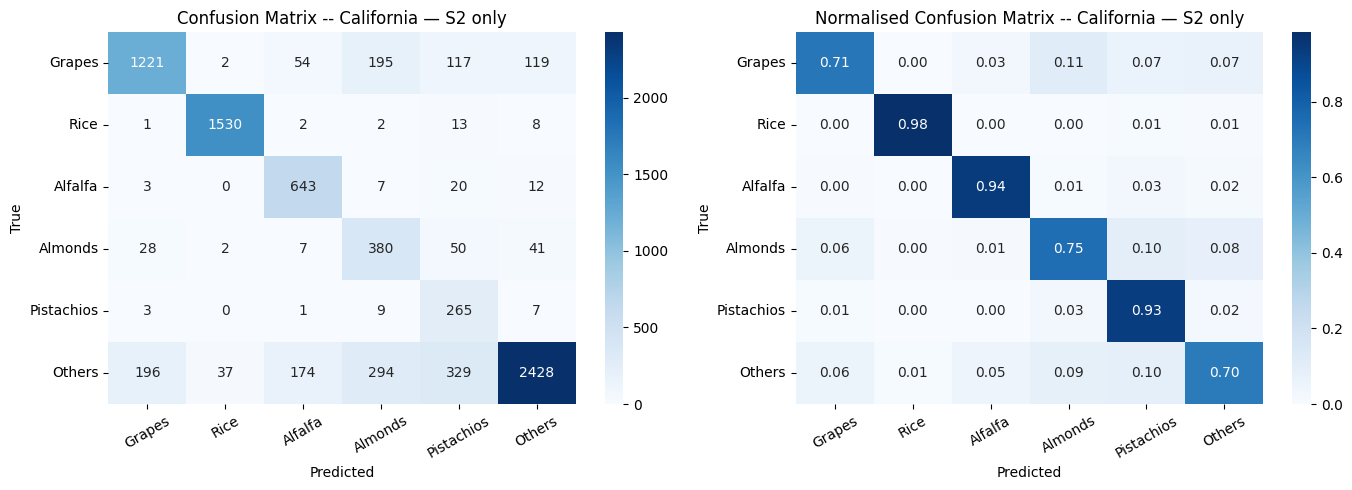

  ✓ Model saved → mctnet_california_s2_only.keras

State: California  |  Config: S2 + Climate
Covariates used: 108 columns  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] …
  Single-gate mode (one group: ['Climate'])
Parameters: 38,927
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 146ms/step - accuracy: 0.5757 - loss: 1.3185 - val_accuracy: 0.3250 - val_loss: 1.6532 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7708 - loss: 0.9163 - val_accuracy: 0.2833 - val_loss: 1.7774 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8208 - loss: 0.7912 - val_accuracy: 0.2833 - val_loss: 1.8507 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8590 - loss: 0.7136 - val_accuracy: 0.2917 - val_loss: 1.9256 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8806 - loss: 0.6580 - val_accuracy: 0.3139 - val_loss: 1.9047 

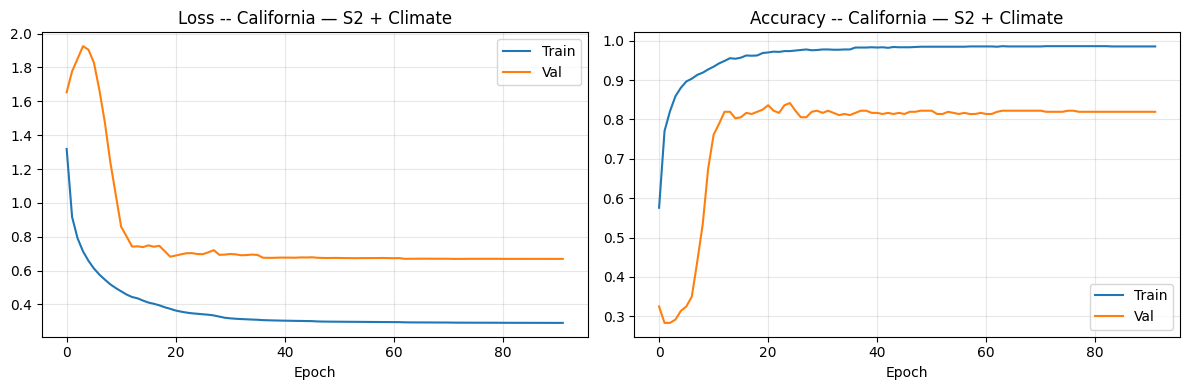


--- California — S2 + Climate Test Results ---
OA=0.8178  Kappa=0.7616  F1=0.7748
              precision    recall  f1-score   support

      Grapes       0.81      0.80      0.81      1708
        Rice       0.98      0.98      0.98      1556
     Alfalfa       0.83      0.91      0.87       685
     Almonds       0.45      0.79      0.57       508
  Pistachios       0.45      0.93      0.60       285
      Others       0.93      0.73      0.81      3458

    accuracy                           0.82      8200
   macro avg       0.74      0.86      0.77      8200
weighted avg       0.86      0.82      0.83      8200



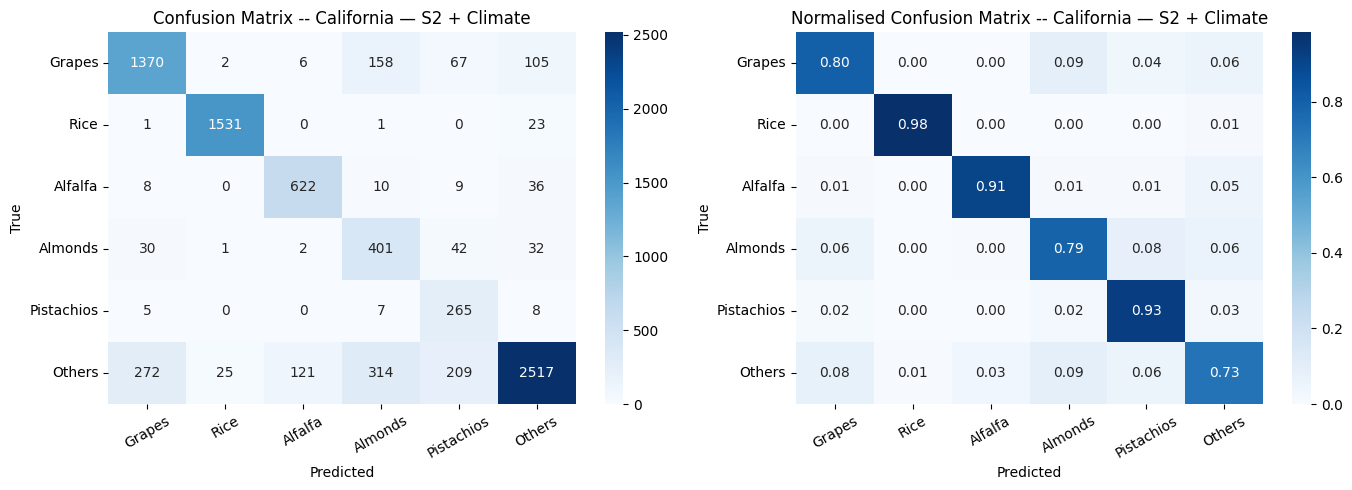

  ✓ Model saved → mctnet_california_s2_plus_climate.keras

  Gate Values (mean over test set):
  Climate        : 0.391 +/- 0.381  |#######


State: California  |  Config: S2 + Soil
Covariates used: 3 columns  ['soil_organic_carbon_g_kg', 'soil_pH', 'soil_texture_class']
  Single-gate mode (one group: ['Soil'])
Parameters: 32,492
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 111ms/step - accuracy: 0.5528 - loss: 1.2792 - val_accuracy: 0.2472 - val_loss: 1.7699 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7542 - loss: 0.8778 - val_accuracy: 0.1917 - val_loss: 1.8597 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8215 - loss: 0.7588 - val_accuracy: 0.1694 - val_loss: 1.9423 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8479 - loss: 0.6809 - val_accuracy: 0.1917 - val_loss: 1.9438 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accu

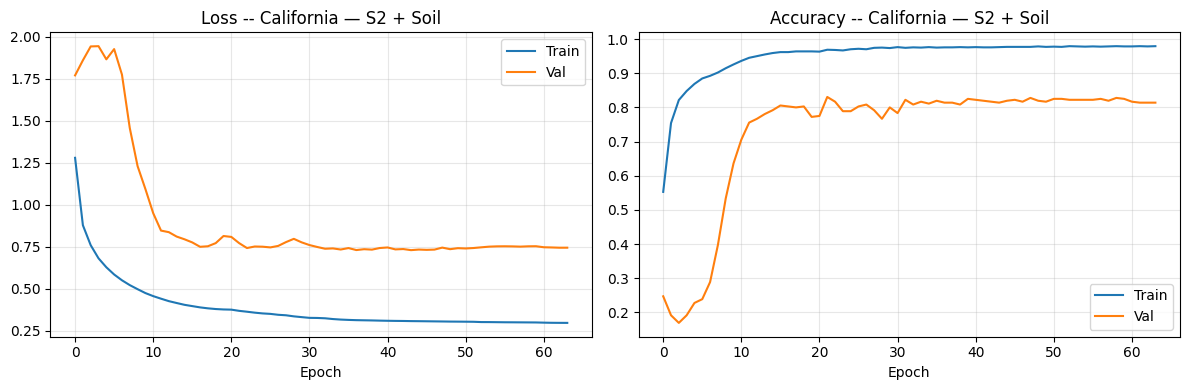


--- California — S2 + Soil Test Results ---
OA=0.8046  Kappa=0.7463  F1=0.7556
              precision    recall  f1-score   support

      Grapes       0.82      0.78      0.80      1708
        Rice       0.99      0.99      0.99      1556
     Alfalfa       0.84      0.91      0.87       685
     Almonds       0.41      0.77      0.53       508
  Pistachios       0.38      0.92      0.53       285
      Others       0.94      0.71      0.81      3458

    accuracy                           0.80      8200
   macro avg       0.73      0.85      0.76      8200
weighted avg       0.86      0.80      0.82      8200



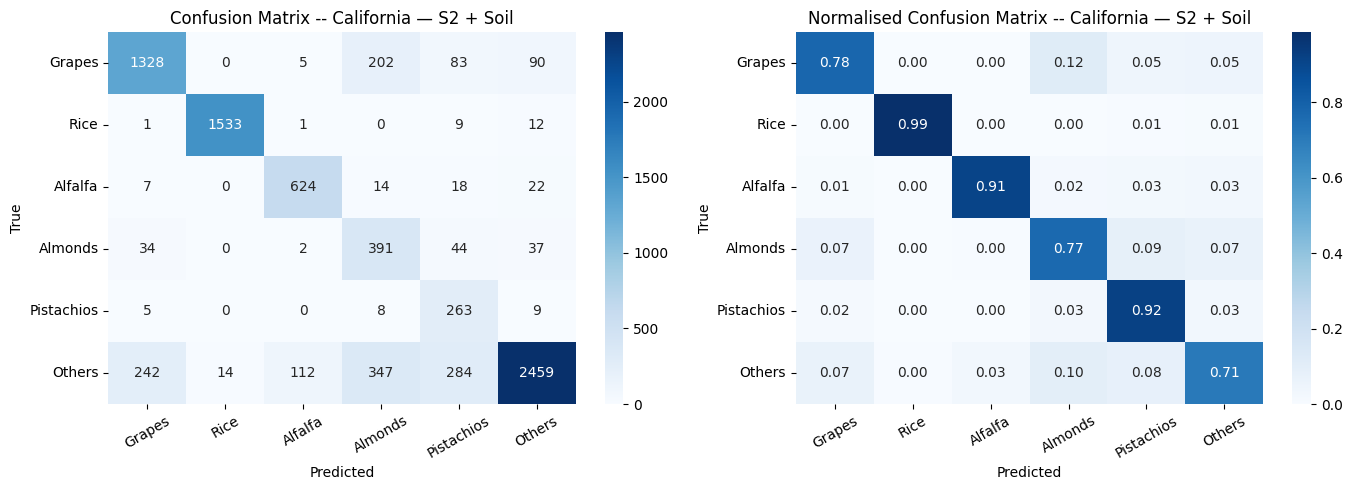

  ✓ Model saved → mctnet_california_s2_plus_soil.keras

  Gate Values (mean over test set):
  Soil           : 0.280 +/- 0.136  |#####


State: California  |  Config: S2 + Topography
Covariates used: 2 columns  ['topo_elevation_m', 'topo_landform_class']
  Single-gate mode (one group: ['Topography'])
Parameters: 32,557
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 142ms/step - accuracy: 0.5521 - loss: 1.2789 - val_accuracy: 0.2583 - val_loss: 1.7645 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7514 - loss: 0.8769 - val_accuracy: 0.1972 - val_loss: 1.8375 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8153 - loss: 0.7587 - val_accuracy: 0.2139 - val_loss: 1.8507 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8451 - loss: 0.6793 - val_accuracy: 0.1972 - val_loss: 1.9768 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.867

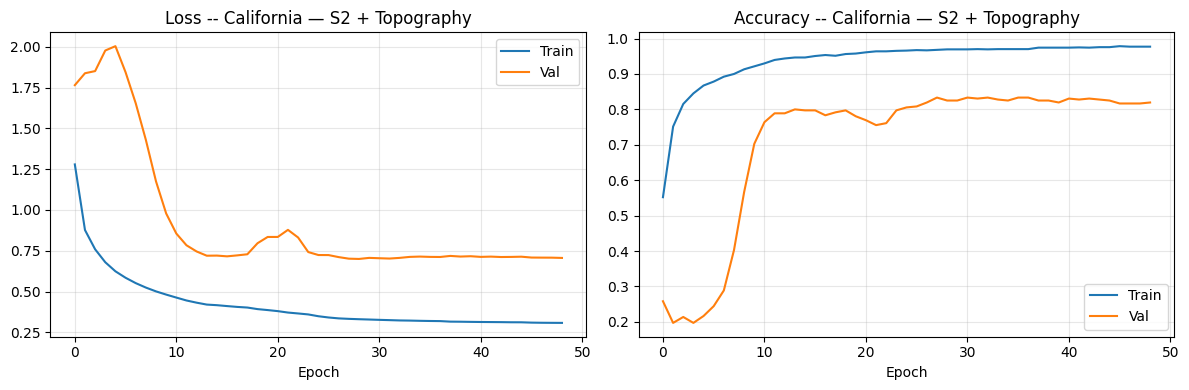


--- California — S2 + Topography Test Results ---
OA=0.8077  Kappa=0.7492  F1=0.7571
              precision    recall  f1-score   support

      Grapes       0.83      0.77      0.80      1708
        Rice       0.99      0.98      0.99      1556
     Alfalfa       0.85      0.92      0.88       685
     Almonds       0.42      0.75      0.54       508
  Pistachios       0.37      0.91      0.52       285
      Others       0.92      0.73      0.81      3458

    accuracy                           0.81      8200
   macro avg       0.73      0.84      0.76      8200
weighted avg       0.86      0.81      0.82      8200



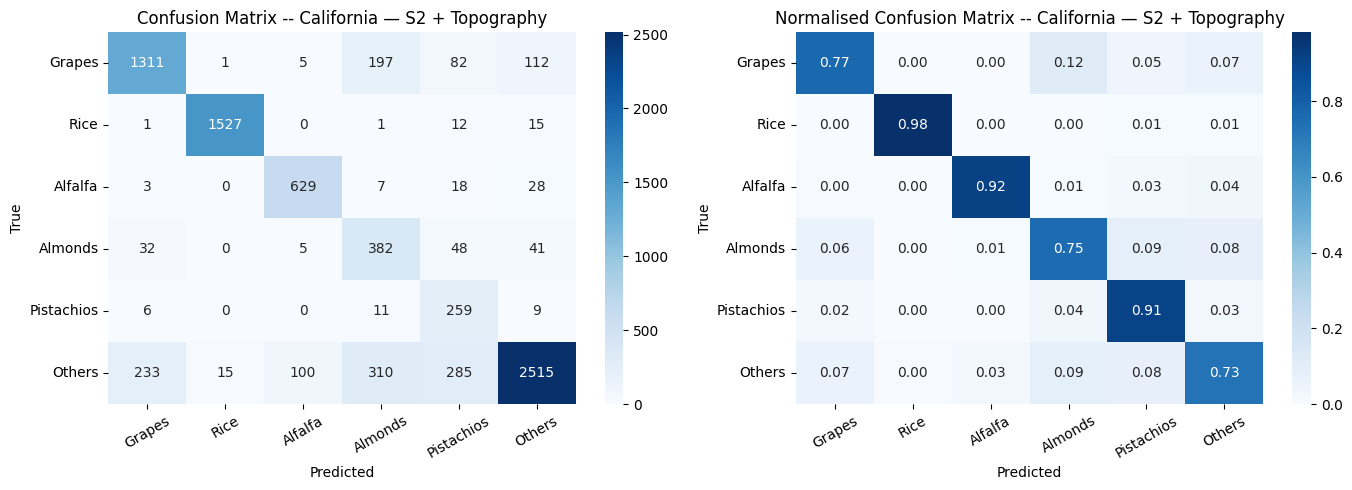

  ✓ Model saved → mctnet_california_s2_plus_topography.keras

  Gate Values (mean over test set):
  Topography     : 0.076 +/- 0.041  |#


State: California  |  Config: S2 + All
Covariates used: 113 columns  ['clim_temp_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_temp_mean_C_t03'] …
  Per-group gating: [('Climate', 108), ('Soil', 9), ('Topography', 10)]
Parameters: 33,603
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - accuracy: 0.4521 - loss: 2.0052 - val_accuracy: 0.1806 - val_loss: 2.1148 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7493 - loss: 0.9372 - val_accuracy: 0.1806 - val_loss: 1.8449 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8118 - loss: 0.8017 - val_accuracy: 0.2083 - val_loss: 1.8403 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8278 - loss: 0.7203 - val_accuracy: 0.1972 - val_loss: 1.8545 - learning_rate: 0.0010
Epoch 5/200
45/4

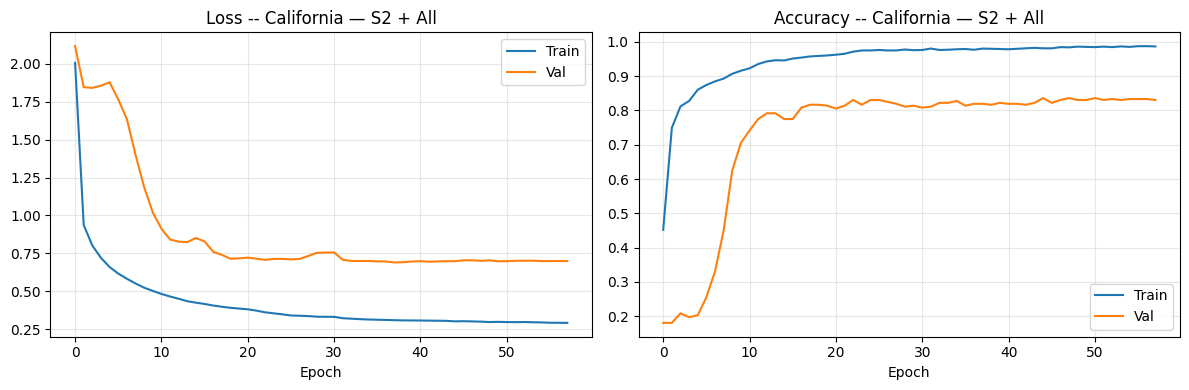


--- California — S2 + All Test Results ---
OA=0.8315  Kappa=0.7773  F1=0.7876
              precision    recall  f1-score   support

      Grapes       0.81      0.78      0.80      1708
        Rice       0.98      0.99      0.98      1556
     Alfalfa       0.87      0.91      0.89       685
     Almonds       0.48      0.76      0.59       508
  Pistachios       0.47      0.95      0.63       285
      Others       0.92      0.77      0.84      3458

    accuracy                           0.83      8200
   macro avg       0.76      0.86      0.79      8200
weighted avg       0.86      0.83      0.84      8200



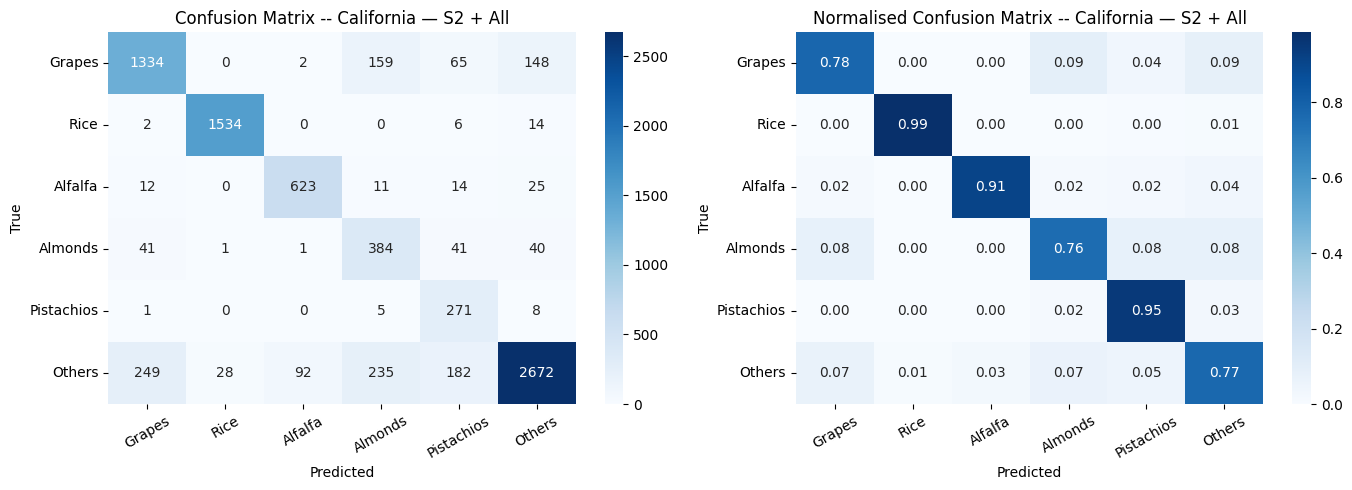

  ✓ Model saved → mctnet_california_s2_plus_all.keras

  Gate Values (mean over test set):
  Climate        : 0.577 +/- 0.332  |###########
  Soil           : 0.138 +/- 0.037  |##
  Topography     : 0.075 +/- 0.027  |#



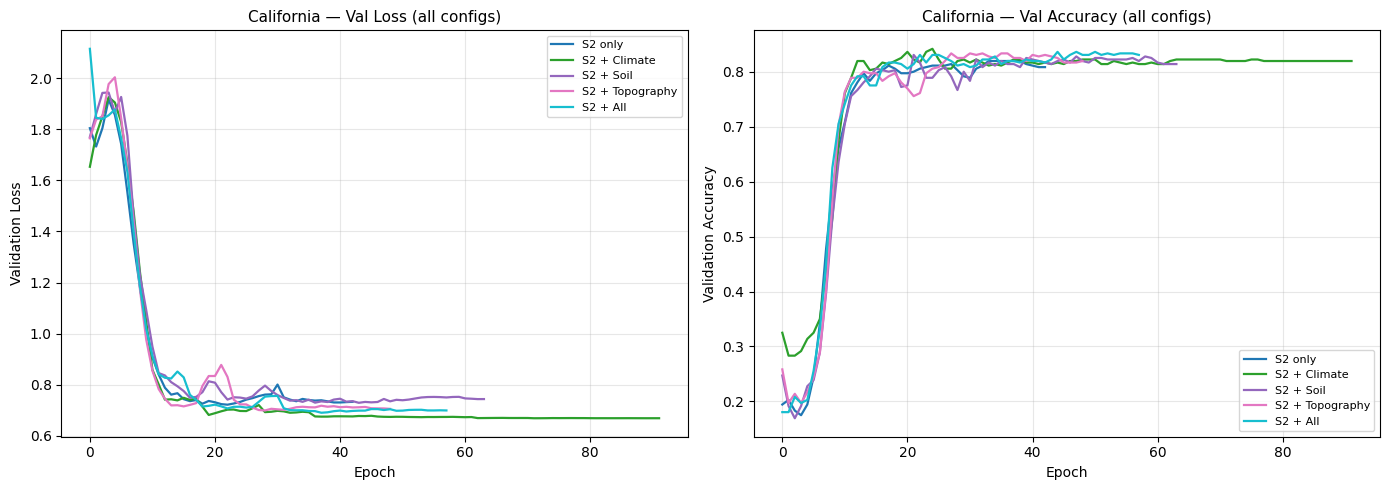


===== California Ablation Results =====
         Config     OA  Kappa  F1-macro  Params
        S2 only 0.7887 0.7267    0.7347   29570
   S2 + Climate 0.8178 0.7616    0.7748   38927
      S2 + Soil 0.8046 0.7463    0.7556   32492
S2 + Topography 0.8077 0.7492    0.7571   32557
       S2 + All 0.8315 0.7773    0.7876   33603


In [19]:
ablation_ca = run_ablation(
    state         = 'California',
    label_map     = CA_LABELS,
    class_names   = ca_classes,
    full_train    = ca_train,
    full_val      = ca_val,
    full_test     = ca_test,
    covar_encoder = ca_enc,
    configs       = ABLATION_CONFIGS,
)
print('\n===== California Ablation Results =====')
print(ablation_ca.to_string(index=False))


### 3.5 Ablation Summary Visualisation

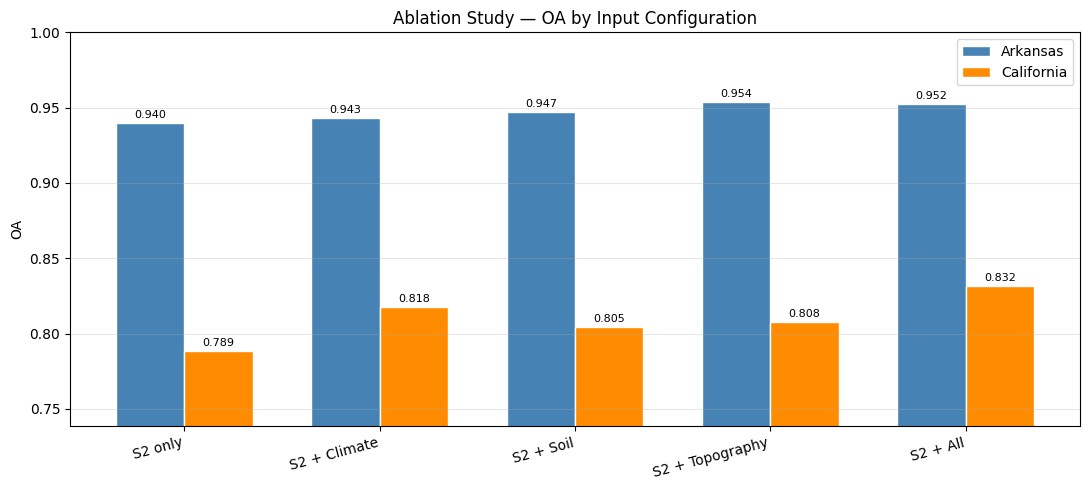

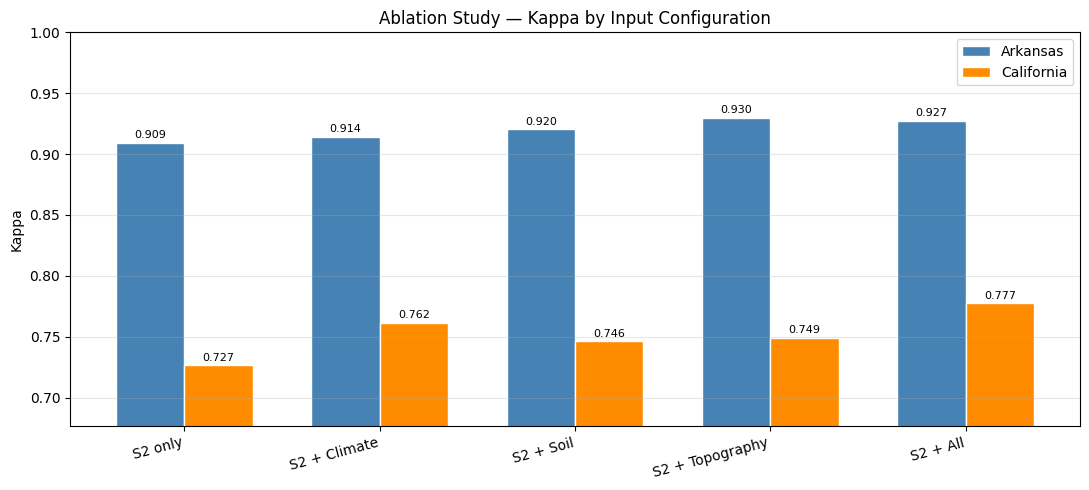

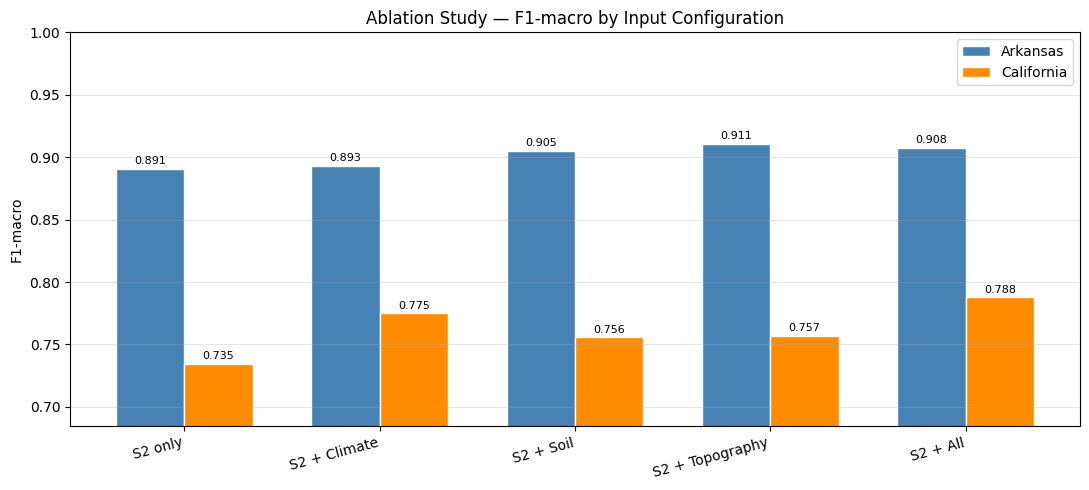


===== Combined Ablation Table =====
         Config  OA_AR  Kappa_AR  F1_AR  Params_AR  OA_CA  Kappa_CA  F1_CA  Params_CA
        S2 only 0.9399    0.9095 0.8906      29489 0.7887    0.7267 0.7347      29570
   S2 + Climate 0.9431    0.9141 0.8933      38814 0.8178    0.7616 0.7748      38927
      S2 + Soil 0.9474    0.9204 0.9052      32379 0.8046    0.7463 0.7556      32492
S2 + Topography 0.9539    0.9298 0.9106      32379 0.8077    0.7492 0.7571      32557
       S2 + All 0.9522    0.9273 0.9076      33491 0.8315    0.7773 0.7876      33603


In [20]:
def plot_ablation_summary(ablation_ar, ablation_ca, metric='OA'):
    """Side-by-side bar chart comparing configurations across both states."""
    configs = ablation_ar['Config'].tolist()
    x       = np.arange(len(configs))
    width   = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - width/2, ablation_ar[metric], width,
                   label='Arkansas',   color='steelblue',  edgecolor='white')
    bars2 = ax.bar(x + width/2, ablation_ca[metric], width,
                   label='California', color='darkorange', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=15, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'Ablation Study — {metric} by Input Configuration')
    ax.legend()
    ax.set_ylim(max(0, min(ablation_ar[metric].min(),
                            ablation_ca[metric].min()) - 0.05), 1.0)
    ax.grid(alpha=0.3, axis='y')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

for metric in ['OA', 'Kappa', 'F1-macro']:
    plot_ablation_summary(ablation_ar, ablation_ca, metric)

print('\n===== Combined Ablation Table =====')
combined = ablation_ar.rename(columns={'OA':'OA_AR','Kappa':'Kappa_AR','F1-macro':'F1_AR',
                                        'Params':'Params_AR'}
                               ).merge(
    ablation_ca.rename(columns={'OA':'OA_CA','Kappa':'Kappa_CA','F1-macro':'F1_CA',
                                  'Params':'Params_CA'}),
    on='Config'
)
print(combined.to_string(index=False))


In [21]:
ablation_ar.to_csv(os.path.join(FOLDER, 'ablation_arkansas.csv'), index=False)
ablation_ca.to_csv(os.path.join(FOLDER, 'ablation_california.csv'), index=False)
combined.to_csv(os.path.join(FOLDER, 'ablation_combined.csv'), index=False)
print('Ablation results saved.')


Ablation results saved.
